In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM as LETLMC
from Python_files import IETLM as IETLMC
torch.set_default_dtype(torch.float64)


In [2]:
def eigen_finder_kth(Pi, k):
    eigenvals, eigenvecs = torch.linalg.eigh(Pi)
    magnitudes = torch.abs(eigenvals)
    values, indices = torch.topk(magnitudes, k, largest=False)
    smallest_eigenvals = eigenvals[indices]
    smallest_eigenvecs = eigenvecs[:, indices]
    return smallest_eigenvecs, eigenvals

In [3]:
def eigen_finder_abs(Pi, threshold):
    eigenvals, eigenvecs = torch.linalg.eig(Pi)
    magnitudes = torch.abs(eigenvals)
    zero_eigenvals = []
    zero_eigenvecs = []
    for i in range(len(eigenvals)):
        if magnitudes[i] <= threshold:
            zero_eigenvals.append(eigenvals[i])
            zero_eigenvecs.append(eigenvecs[i])
    return zero_eigenvecs, zero_eigenvals


In [4]:
def eigen_finder_scaled(Pi, threshold):
    eigenvals, eigenvecs = torch.linalg.eig(Pi)
    magnitudes = torch.abs(eigenvals)
    total_mag = torch.sum(magnitudes)
    border = total_mag * threshold
    zero_eigenvals = []
    zero_eigenvecs = []
    for i in range(len(eigenvals)):
        if magnitudes[i] <= border:
            zero_eigenvals.append(eigenvals[i])
            zero_eigenvecs.append(eigenvecs[i])
    return zero_eigenvecs, zero_eigenvals


In [5]:
def spin_up(x, model_parameters, model,spin_up_time):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in = x

    for i in range(spin_up_time):
        x_out = model(x_in, model_parameters)
        # print(x_out.shape)
        x_in = x_out
    return x_out

In [6]:

def stencil_selector(grid_index, Ensemble, N, ensemble_size,stencil_members):

    i = grid_index
    # print(i)
    # print(stencil_members)

    subset = torch.zeros(len(stencil_members), ensemble_size)
    # print(subset.shape)
    for ii in range(len(stencil_members)):
        j = grid_index + stencil_members[ii]
        # print(j)
        subset[(ii%N),:] = Ensemble[(j%N),:]
        

    return subset

In [7]:

# def put_in_place_row(x_i, N, x_tilde, grid_index, stencil_members):
#     print("x_i shape:", x_i.shape)
#     print("x_i:", x_i)
#     print("stencil_members:", stencil_members)
#     # print(len(stencil_members))
#     # print(n_i.shape)
#     sub_row = torch.zeros(1,N)
#     for i in range(len(stencil_members)):
#         local = grid_index + stencil_members[i]
#         print(i, local)
#         sub_row[local%N] = x_i[i]
#     x_tilde = torch.stack((x_tilde, sub_row))
#     return x_tilde

def put_in_place_row(x_i, N, x_tilde, grid_index, stencil_members):
    # print("x_i shape:", x_i.shape)
    # print("x_i:", x_i)
    # print("stencil_members:", stencil_members)

    sub_row = torch.zeros(1, N)

    for i in range(len(stencil_members)):
        local = grid_index + stencil_members[i]
        # print(i, local)

        sub_row[0, local % N] = x_i[i]

    x_tilde = torch.cat((x_tilde, sub_row), dim=0)

    return x_tilde



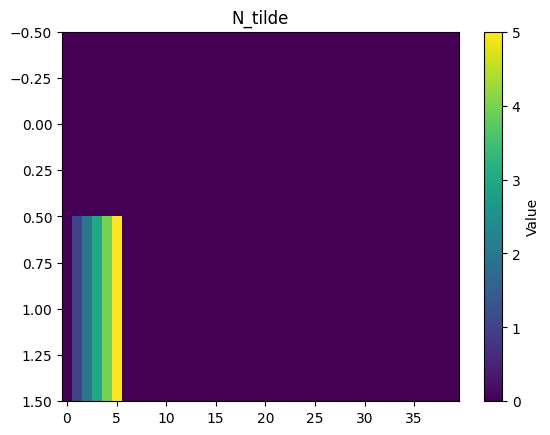

In [8]:
#  we are going to test the put in place row function
x_i = [1,2,3,4,5]
N = 40
x_tilde = torch.zeros(1,N)
grid_index = 3
stencil_members = [-2,-1,0,1,2]
result = put_in_place_row(x_i, N, x_tilde, grid_index, stencil_members)

plt.imshow(result,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N_tilde")
plt.show()

In [9]:
# We will define a function that generates the GETLM at each gridpoint
def little_GETLM(Chi_i, Xi_i, X_i, k):
    # Construct matrix
    Pi_half = torch.cat((Chi_i,-Xi_i, -X_i), dim=0)
    Pi = Pi_half @ Pi_half.T

    # print(Pi_half.shape)

    # We now need to find the zero-eigenvalue eigenvectors
    zero_eigenvalue_eigenvecs, eigenvalues = eigen_finder_kth(Pi,k)
    return zero_eigenvalue_eigenvecs, eigenvalues

In [10]:
def member_splitter(zero_eigenvalue_eigenvector, stencil_members_large):
    # print(zero_eigenvalue_eigenvector.shape)
    split_1 = len(stencil_members_large[0])
    split_2 = len(stencil_members_large[1])
    split_3 = len(stencil_members_large[2])
    splits = [split_1, split_2, split_3]
    # print(splits)
    # print(zero_eigenvalue_eigenvector)
    # n_i = zero_eigenvalue_eigenvector[:split_1]
    # l_i = zero_eigenvalue_eigenvector[split_1: split_2]
    # k_i = zero_eigenvalue_eigenvector[split_2:]
    (n_i, l_i, k_i) = torch.split(zero_eigenvalue_eigenvector, splits, dim=0)

    return n_i, l_i, k_i



In [11]:
def GETLM_generator(Chi, Xi, X, stencil_members_large, model_parameters, ensemble_size, k, plot = True):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    N_tilde = torch.zeros(1,N)
    L_tilde = torch.zeros(1,N)
    K_tilde = torch.zeros(1,N)
    eigenvalues_4_plot = []

    future_members = stencil_members_large[0]
    current_members = stencil_members_large[1]
    past_members = stencil_members_large[2]
    for grid_index in range(N):


        X_i = stencil_selector(grid_index, X, N, ensemble_size,past_members)
        Xi_i = stencil_selector(grid_index, Xi, N, ensemble_size,current_members)
        Chi_i = stencil_selector(grid_index, Chi, N, ensemble_size,future_members)
        # print(Xi_i.shape)

        zeros, eigenvalues = little_GETLM(Chi_i, Xi_i, X_i, k)
        eigenvalues_4_plot.append(eigenvalues)

        # print(zeros.shape)
        zeros = torch.transpose(zeros, 0, 1)
        for i in range(len(zeros)):
            zero_eigenvalue_eigenvector = zeros[i]
            # print(zero_eigenvalue_eigenvector)
            # We now need to split the eigenvectors in the components for n, l and k
            n_i, l_i, k_i = member_splitter(zero_eigenvalue_eigenvector, stencil_members_large)
            # print('n_i', n_i)
            # print('l_i', l_i)
            # print('k_i', k_i)

            # We now need to put n_i, l_i and k_i into place 
            N_tilde = put_in_place_row(n_i, N, N_tilde, grid_index, future_members)
            L_tilde = put_in_place_row(l_i, N, L_tilde, grid_index, current_members)
            K_tilde = put_in_place_row(k_i, N, K_tilde, grid_index, past_members)

    N_tilde= N_tilde[1:]
    L_tilde= L_tilde[1:]
    K_tilde= K_tilde[1:]

    if plot == True:
        x_coords = []
        y_coords = []

        for grid_idx, eigenvalues in enumerate(eigenvalues_4_plot):
            # Repeat the current grid index for every eigenvalue in this cell
            x_coords.extend([grid_idx] * len(eigenvalues))
            # Add the actual eigenvalues to the y-list
            y_coords.extend(eigenvalues)

        # 3. Create the plot
        plt.figure(figsize=(12, 6))

        # Use a small marker size (s) and slight transparency (alpha) 
        # to see overlapping values or high density clearly
        plt.scatter(x_coords, y_coords, alpha=0.6, s=15, color='blue', edgecolors='none')

        # Formatting the plot
        plt.yscale('log')
        plt.title("Eigenvalue Spectrum per Grid Cell", fontsize=14, fontweight='bold')
        plt.xlabel("Grid Point Index (Columns)", fontsize=12)
        plt.ylabel("Eigenvalue Magnitude (Rows)", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()
        

    
    return  N_tilde, L_tilde, K_tilde



In [12]:
# We will now test this function
# We will start with Crank-Nicolson 


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)

100%|██████████| 999/999 [00:00<00:00, 11782.48it/s]

[tensor([8.0000]), tensor([8.0000])]


In [13]:
# This works for a single time step
# We are going to start by defining a function that will generate ensembles for the GETLM 
def GETLM_ensemble_generator(x_current, x_past, ensemble_size, standard_deviation,model,model_parameters, number_of_steps = 1):
    (N, dx, dt, alpha, beta, F_L96)  = model_parameters

    # The first step is to perturb the inputed run
    # We start by making 'ensemble size' copies of the input vector
    x_current_matrix = x_current.repeat(N, ensemble_size)
    x_past_matrix = x_past.repeat(N, ensemble_size)
    # print(x_current_matrix.shape)
    # print(x_past_matrix.shape)



    
    # We are now going to add random normal noise to this matrix to give us our original function 
    X = x_current_matrix + torch.randn(N, ensemble_size) * standard_deviation
    Xi = torch.zeros(N, ensemble_size)
    Chi = torch.zeros(N, ensemble_size)
    # We now iterate though each of the ensemble members to run the model
    for member in range(ensemble_size):
        # print('member:', member)
        state_pert = [X[:,member], x_past_matrix[:,member]]
        state = [x_current_matrix[:,member], x_past_matrix[:,member]]
        # print(state)
        # print(state[0])

        state_pert = TST.run_model(state_pert, model, model_parameters)
        state_pert = TST.run_model(state_pert, model, model_parameters)

        state = TST.run_model(state, model, model_parameters)
        
        state = TST.run_model(state, model, model_parameters)
        # print(state_pert[0].shape) 
        # print(state[0].shape)
        # print(state_pert[0].shape)
        
        # print(state_pert[0].shape)

        # print(state[0].shape)
        # print(Xi[:, member].shape)

        Xi[:, member] = (state_pert[0] - state[0]).squeeze()
        Chi[:, member] = (state_pert[1] - state[1]).squeeze()

    return Chi, Xi, X


        



In [14]:
# We will now test this function
# We will start with Crank-Nicolson 


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)

100%|██████████| 999/999 [00:00<00:00, 14951.27it/s]

[tensor([8.0000]), tensor([8.0000])]


In [15]:
# We will now test out the ensemble generator 
model = TST.CN_L96
# print(x_out)
stencil_members_future = [-2,-1,0,1]
stencil_members_current= [-2,-1,0,1]
stencil_members_past = [0]
stencil_members_large = [stencil_members_future, stencil_members_current, stencil_members_past]
ensemble_size = len(stencil_members_future) + len(stencil_members_current) + len(stencil_members_past) + 5

Chi, Xi, X = GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size, 10**(-7),model,model_parameters)

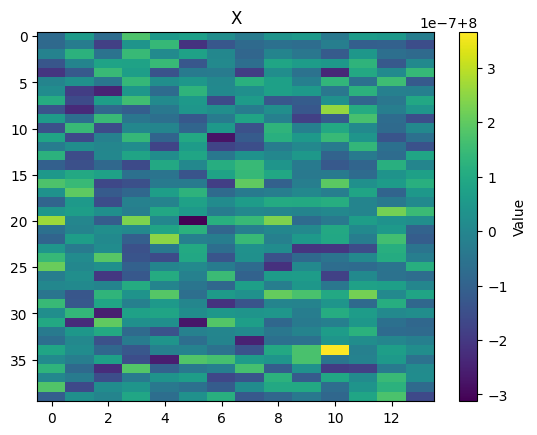

In [16]:
plt.imshow(X,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("X")
plt.show()

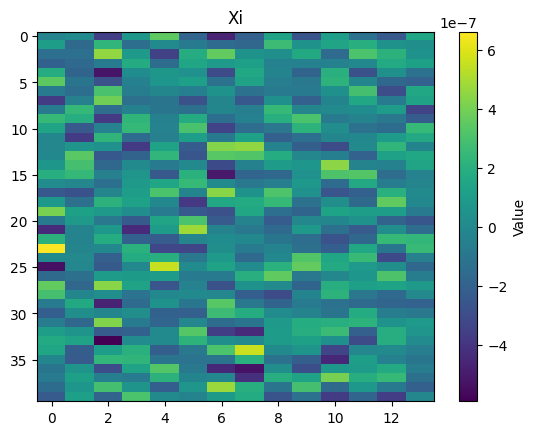

In [17]:
plt.imshow(Xi,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Xi")
plt.show()

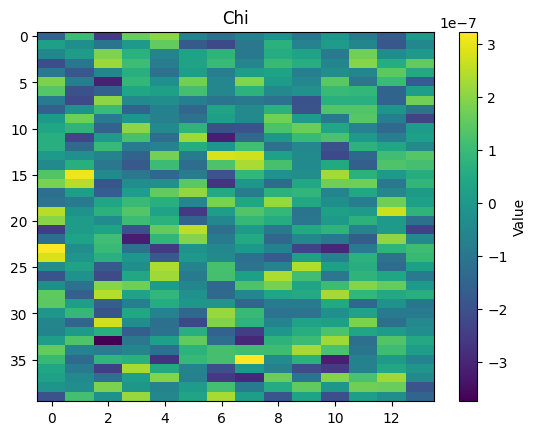

In [18]:
plt.imshow(Chi,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Chi")
plt.show()

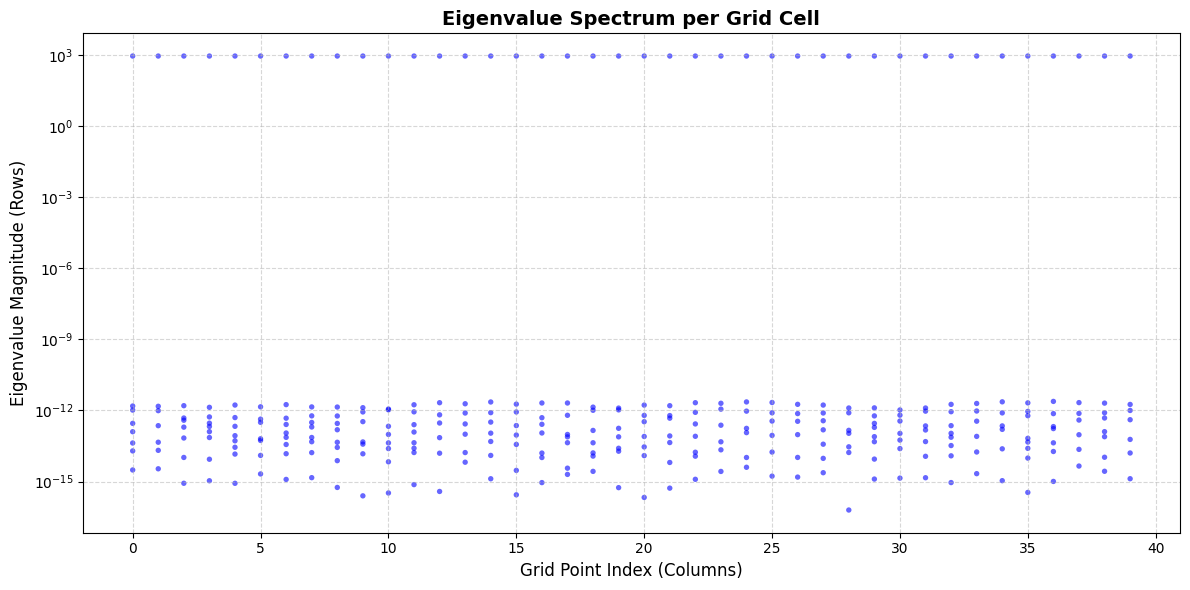

In [19]:
# Now that we have our ensembles made we can now test the GETLM 
# stencil_members_future = [-1,0,1]
# stencil_members_current= [-1,0,1]
# stencil_members_past = [0]
# stencil_members_large = [stencil_members_future, stencil_members_current, stencil_members_past]
# ensemble_size = len(stencil_members_future) + len(stencil_members_current) + len(stencil_members_past) + 5
k = 4 # number of zero eigenvalue eigenvalues


N_tilde, L_tilde, K_tilde = GETLM_generator(Chi, Xi, X, stencil_members_large, model_parameters, ensemble_size, k)

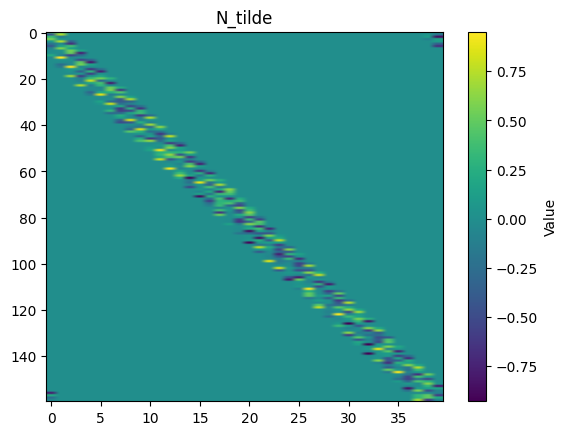

In [20]:
plt.imshow(N_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N_tilde")
plt.show()

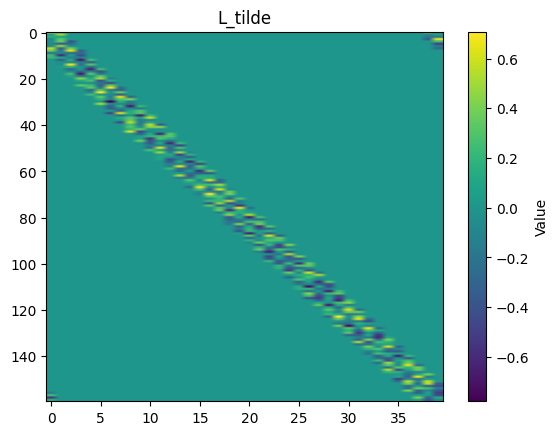

tensor([ 0.6629, -0.1847,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.4007, -0.0599])


In [21]:
plt.imshow(L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("L_tilde")
plt.show()
print(L_tilde[0,:])

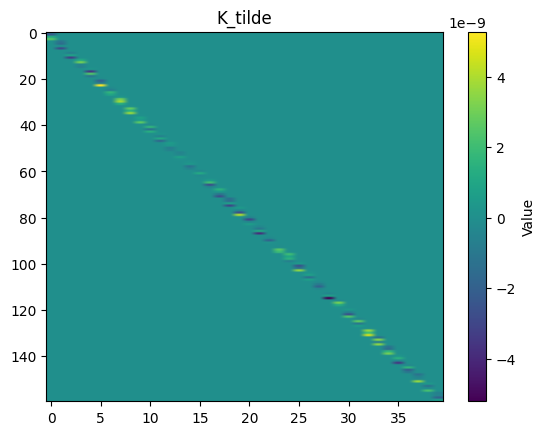

tensor([-1.0704e-09,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00])


In [22]:
plt.imshow(K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("K_tilde")
plt.show()
print(K_tilde[0,:])

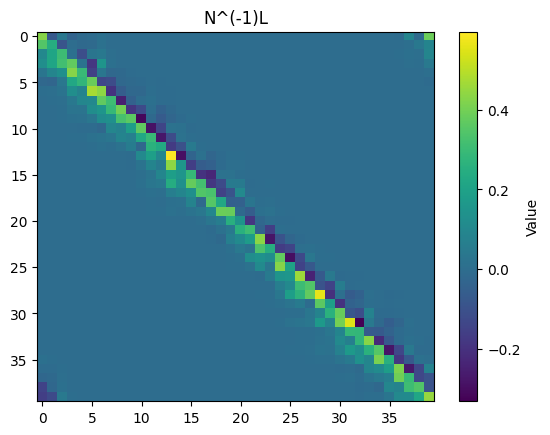

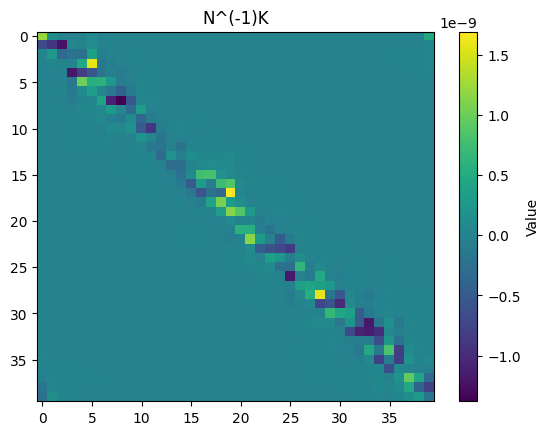

In [23]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [24]:
# We will now test this function
# We will now do Leapfrog


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)

100%|██████████| 999/999 [00:00<00:00, 15711.48it/s]

[tensor([8.0000]), tensor([8.0000])]


In [25]:
# We will now attempt to find the GETLM of the Leapfrog time integration of the L96 model
# We will now test out the ensemble generator 
# print(x_out)
stencil_members_future = [-2,-1,0,1,2]
stencil_members_current= [-2,-1,0,1,2]
stencil_members_past = [0]
stencil_members_large = [stencil_members_future, stencil_members_current, stencil_members_past]
ensemble_size = len(stencil_members_future) + len(stencil_members_current) + len(stencil_members_past) + 5



Chi, Xi, X = GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size, 10**(-7),model,model_parameters)

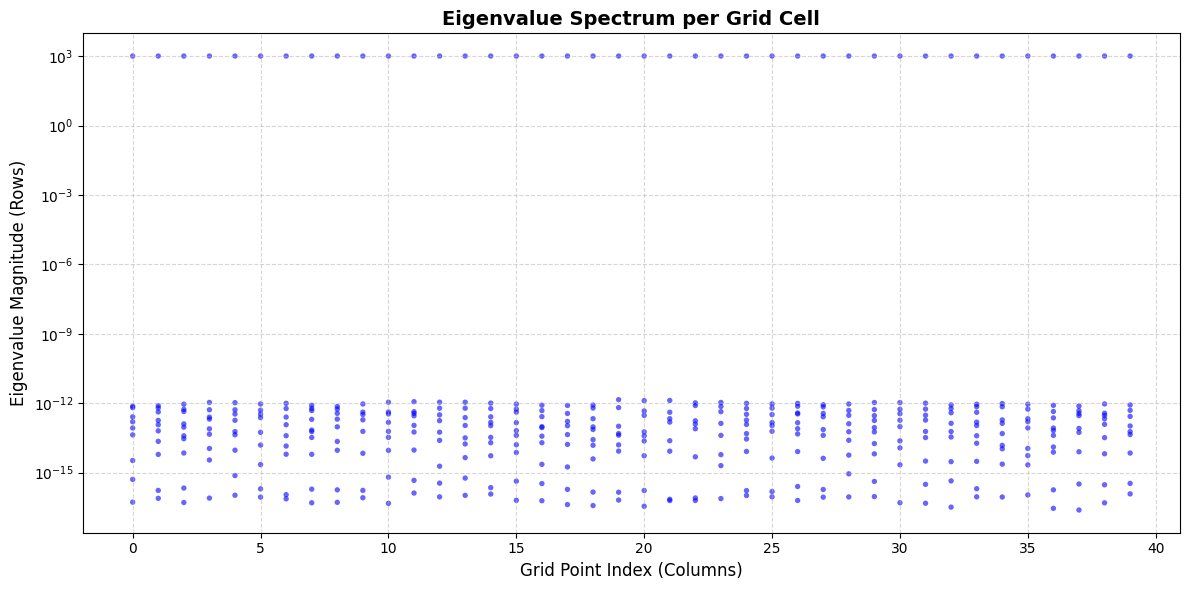

In [26]:
k = 2 # number of zero eigenvalue eigenvalues


N_tilde, L_tilde, K_tilde = GETLM_generator(Chi, Xi, X, stencil_members_large, model_parameters, ensemble_size, k)

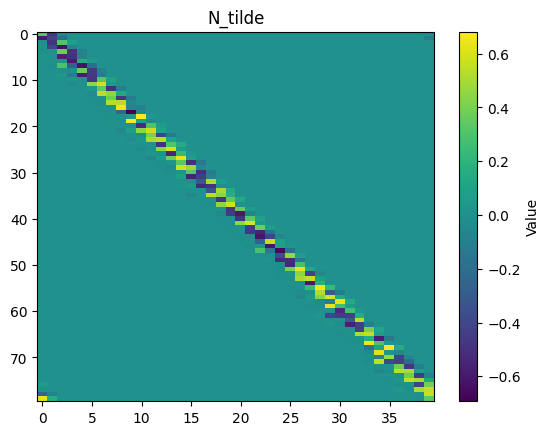

In [27]:
plt.imshow(N_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N_tilde")
plt.show()

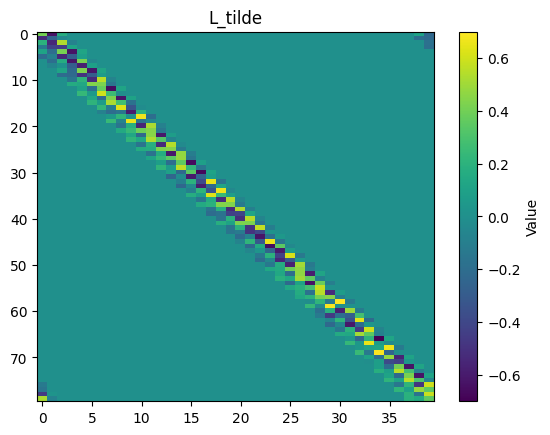

In [28]:
plt.imshow(L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("L_tilde")
plt.show()

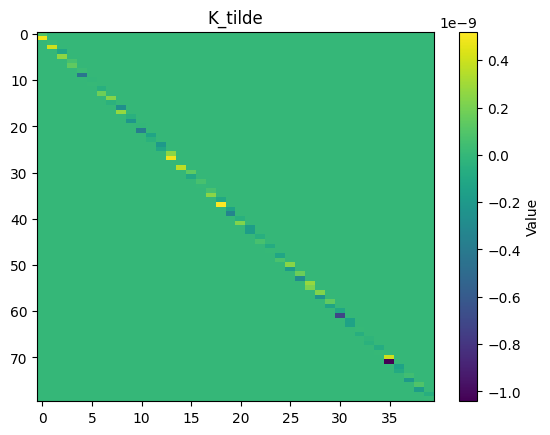

In [29]:
plt.imshow(K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("K_tilde")
plt.show()

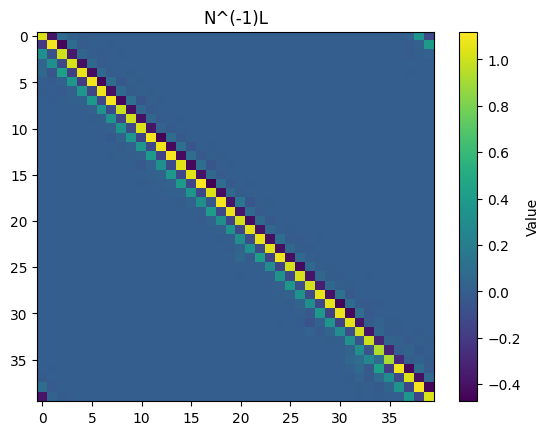

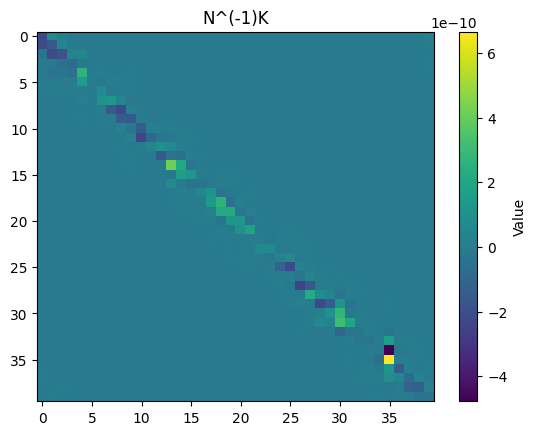

In [30]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [31]:
# I will now modify the GETLM ensemble generator to be able to generate ensembles of multiple time steps 
# We are going to start by defining a function that will generate ensembles for the GETLM 

def GETLM_ensemble_generator_mult(x_current, x_past, ensemble_size, standard_deviation,model,model_parameters, number_of_steps = 1):
    (N, dx, dt, alpha, beta, F_L96)  = model_parameters
    Ensembles = []
    test = [torch.rand((N,1)) * standard_deviation,torch.zeros(N,1)]
    test_values = [test]
    # The first step is to perturb the inputed run
    # We start by making 'ensemble size' copies of the input vector
    x_current_matrix = x_current.repeat(N, ensemble_size)
    x_past_matrix = x_past.repeat(N, ensemble_size)
    # print(x_current_matrix.shape)
    # print(x_past_matrix.shape)


    
    # We are now going to add random normal noise to this matrix to give us our original function 
    X = x_current_matrix + torch.randn(N, ensemble_size) * standard_deviation
    Xi = torch.zeros(N, ensemble_size)
    Chi = torch.zeros(N, ensemble_size)
    
    # # We now iterate though each of the ensemble members to run the model

    # for i in range(number_of_steps):


    # --- BEFORE THE LOOP (Initialization) ---
    # Initialize test state as a self-sustaining trajectory 
    state_test = [x_current + (torch.rand((N, 1)) * standard_deviation), x_past.clone()]

    # Inside the loop:
    for i in range(number_of_steps):
        
        # --- PART A: EVOLVE CONTROL & TEST TRAJECTORIES ---
        # Advance both forward naturally from their respective previous states
        control_state = TST.run_model(control_state, model, model_parameters)
        state_test = TST.run_model(state_test, model, model_parameters)
        
        # Compute the true, unforced divergence at this timestamp
        test = [state_test[0] - control_state[0], state_test[1] - control_state[1]]
        test_values.append(test)



        for member in range(ensemble_size):
            # print('member:', member)
            state_pert = [X[:,member], x_past_matrix[:,member]]
            state = [x_current_matrix[:,member], x_past_matrix[:,member]]
            # print(state)
            # print(state[0])

            state_pert = TST.run_model(state_pert, model, model_parameters)
            state_pert = TST.run_model(state_pert, model, model_parameters)


            state_test = state + test_values[-1]
            state = TST.run_model(state, model, model_parameters)
            
            state = TST.run_model(state, model, model_parameters)
            test_temp = TST.run_model(state_test, model, model_parameters)
            test = [test_temp[0] - state[0], test_temp[1] - state[1] ]
            # print(state_pert[0].shape) 
            # print(state[0].shape)
            # print(state_pert[0].shape)
            
            # print(state_pert[0].shape)

            # print(state[0].shape)
            # print(Xi[:, member].shape)

            Xi[:, member] = (state_pert[0] - state[0]).squeeze()
            Chi[:, member] = (state_pert[1] - state[1]).squeeze()
            print(test)
        Ensembles.append([Chi, Xi, X])
        test_values.append(test)
        # print(len(Ensembles))
        X = Xi
        Xi = Chi

    return Ensembles, test_values


        



In [32]:
# Gemini Version
def GETLM_ensemble_generator_mult(x_current, x_past, ensemble_size, standard_deviation, model, model_parameters, number_of_steps = 1):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    Ensembles = []
    
    # Ensure initial test perturbations are distinct 2D shapes [N, 1]
    test = [torch.rand((N, 1)) * standard_deviation, torch.zeros((N, 1))]
    test_values = [test]
    
    # 1. FIX: Use .repeat(1, ensemble_size) instead of (N, ensemble_size)
    # This correctly creates an [N, ensemble_size] matrix if x_current is [N, 1]
    x_current_matrix = x_current.repeat(1, ensemble_size)
    x_past_matrix = x_past.repeat(1, ensemble_size)

    # Initialize perturbed states for the ensemble
    X = x_current_matrix + torch.randn(N, ensemble_size) * standard_deviation
    X_past = x_past_matrix.clone()
    
    # 2. FIX: Track a single unperturbed control trajectory across time steps
    control_state = [x_current.clone(), x_past.clone()]
    for i in range(number_of_steps):
        # Allocate fresh zero matrices per timestep to prevent reference overwriting
        Xi = torch.zeros(N, ensemble_size)
        Chi = torch.zeros(N, ensemble_size)
        
        # --- PART A: EVOLVE CONTROL & TEST TRAJECTORIES (Exactly 1 Step) ---
        # 1. Align test state with current control state
        state_test = [control_state[0] + test_values[-1][0], control_state[1] + test_values[-1][1]]
        
        # 2. Advance both control and test states by exactly ONE step
        control_state = TST.run_model(control_state, model, model_parameters)
        state_test = TST.run_model(state_test, model, model_parameters)
        
        # 3. Compute the linear perturbation growth for this single step
        test = [state_test[0] - control_state[0], state_test[1] - control_state[1]]
        test_values.append(test)
        
        # --- PART B: EVOLVE ENSEMBLE MEMBERS (Exactly 1 Step) ---
        # Track the absolute states for the next iteration step
        X_next = torch.zeros(N, ensemble_size)
        
        for member in range(ensemble_size):
            state_pert = [X[:, member].unsqueeze(1), X_past[:, member].unsqueeze(1)]

            # Advance the absolute state of the ensemble member by ONE step
            state_pert = TST.run_model(state_pert, model, model_parameters)

            # Store the absolute state for the next loop iteration
            X_next[:, member] = state_pert[0].squeeze()

            # Measure deviation relative to the newly evolved control run
            Xi[:, member] = state_pert[0].squeeze() - control_state[0].squeeze()
            Chi[:, member] = state_pert[1].squeeze() - control_state[1].squeeze()
            
        # Save explicit copies of the perturbation matrices for this timestep
        Ensembles.append([Chi.clone(), Xi.clone(), X.clone()])
        
        # Shift the time window forward using absolute physical states
        X_past = X.clone()  # The old current state becomes the new past state
        X = X_next.clone()  # The newly generated absolute state becomes the current state

    # for i in range(number_of_steps):
    #     # 3. FIX: Allocate fresh zero matrices per timestep to prevent reference overwriting
    #     Xi = torch.zeros(N, ensemble_size)
    #     Chi = torch.zeros(N, ensemble_size)
        
    #     # --- PART A: EVOLVE CONTROL & TEST TRAJECTORIES (Once per time step) ---
    #     # 4. FIX: Add elements explicitly. List addition ([a] + [b]) concatenates instead of adding values.
    #     state_test = [control_state[0] + test_values[-1][0], control_state[1] + test_values[-1][1]]
        
    #     # Advance control state (Run twice to match the perturbed step logic)
    #     control_state = TST.run_model(control_state, model, model_parameters)
    #     control_state = TST.run_model(control_state, model, model_parameters)
        
    #     # Advance test state symmetrically
    #     test_temp = TST.run_model(state_test, model, model_parameters)
    #     test_temp = TST.run_model(test_temp, model, model_parameters)
        
    #     # Compute and track the actual linear perturbation growth
    #     test = [test_temp[0] - control_state[0], test_temp[1] - control_state[1]]
    #     test_values.append(test)
        
    #     # # --- PART B: EVOLVE ENSEMBLE MEMBERS ---
    #     # for member in range(ensemble_size):
    #     #     state_pert = [X[:, member], X_past[:, member]]

    #     #     # Advance the perturbed ensemble member
    #     #     state_pert = TST.run_model(state_pert, model, model_parameters)
    #     #     state_pert = TST.run_model(state_pert, model, model_parameters)

    #     #     # Measure deviation relative to the freshly evolved control run
    #     #     Xi[:, member] = state_pert[0].squeeze() - control_state[0].squeeze()
    #     #     Chi[:, member] = state_pert[1].squeeze() - control_state[1].squeeze()
            
    #     # # Save explicit copies of the matrices for this timestep
    #     # Ensembles.append([Chi.clone(), Xi.clone(), X.clone()])
        
    #     # # 5. FIX: Shift the time window forward for the next step iteration
    #     # X_past = X.clone()  # The old current state becomes the new past state
    #     # X = Xi.clone()      # The newly generated state becomes the current state


    #     # --- PART B: EVOLVE ENSEMBLE MEMBERS ---
    #     # Create fresh matrices to store absolute states for the NEXT step
    #     X_next = torch.zeros(N, ensemble_size)
    #     X_past_next = X.clone() # The current absolute state becomes the past absolute state
        
        for member in range(ensemble_size):
            state_pert = [X[:, member], X_past[:, member]]

            # Advance the absolute state
            state_pert = TST.run_model(state_pert, model, model_parameters)
            # state_pert = TST.run_model(state_pert, model, model_parameters)

            # Store the absolute state for the next iteration
            X_next[:, member] = state_pert[0]
            
            # Measure deviation relative to control for saving
            Xi[:, member] = state_pert[0].squeeze() - control_state[0].squeeze()
            Chi[:, member] = state_pert[1].squeeze() - control_state[1].squeeze()
            
        # Save explicit copies of the matrices for this timestep
        Ensembles.append([Chi.clone(), Xi.clone(), X.clone()])
        
        # FIX: Correctly advance the absolute states
        # X_past = X_past_next
        # X = X_next
        Ensembles.append([Chi.clone(), Xi.clone(), X.clone()])
        
        # FIX: Correctly advance the absolute states using clones
        X_past = X.clone()       # The old current absolute state becomes the past absolute state
        X = X_next.clone()

    return Ensembles, test_values

In [33]:
# def GETLM_ensemble_generator_mult(x_current, x_past, ensemble_size, standard_deviation, model, model_parameters, number_of_steps = 1):
#     (N, dx, dt, alpha, beta, F_L96) = model_parameters
#     Ensembles = []
    
#     # Track the control state as a list of absolute states [current, past]
#     control_state = [x_current.clone(), x_past.clone()]
    
#     # Initialize test state as a continuous, independent absolute trajectory
#     # Ensure it's a 2D column vector [N, 1] to match the system dimensions
#     initial_perturbation = torch.rand((N, 1)) * standard_deviation
#     state_test = [x_current.clone() + initial_perturbation, x_past.clone()]
    
#     # Track the initial difference
#     test_values = [[initial_perturbation, torch.zeros((N, 1))]]
    
#     # Create absolute state matrices for the ensemble members [N, ensemble_size]
#     X = x_current.repeat(1, ensemble_size) + torch.randn(N, ensemble_size) * standard_deviation
#     X_past = x_past.repeat(1, ensemble_size)

#     for i in range(number_of_steps):
#         # Fresh perturbation allocation per timestep
#         Xi = torch.zeros(N, ensemble_size)
#         Chi = torch.zeros(N, ensemble_size)
        
#         # --- PART A: EVOLVE CONTROL & TEST TRAJECTORIES ---
#         # Advance both continuous physical trajectories by exactly ONE step
#         control_state = TST.run_model(control_state, model, model_parameters)
#         state_test = TST.run_model(state_test, model, model_parameters)
        
#         # Calculate the true, unforced divergence at this timestep
#         test = [state_test[0] - control_state[0], state_test[1] - control_state[1]]
#         test_values.append(test)
        
#         # --- PART B: EVOLVE ENSEMBLE MEMBERS ---
#         # Matrix to hold absolute states for the next time-step
#         X_next = torch.zeros(N, ensemble_size)
        
#         for member in range(ensemble_size):
#             # Indexing columns drops a dimension, so we use .unsqueeze(1) 
#             # to restore [N, 1] shape required by the RK4 solver
#             state_pert = [X[:, member].unsqueeze(1), X_past[:, member].unsqueeze(1)]

#             # Advance the absolute physical state of the ensemble member
#             state_pert = TST.run_model(state_pert, model, model_parameters)

#             # Store absolute current state for the next step iteration
#             X_next[:, member] = state_pert[0].squeeze()

#             # Measure deviations relative to the newly evolved control run
#             Xi[:, member] = state_pert[0].squeeze() - control_state[0].squeeze()
#             Chi[:, member] = state_pert[1].squeeze() - control_state[1].squeeze()
            
#         # Append copies of the perturbation fields and the baseline absolute state
#         Ensembles.append([Chi.clone(), Xi.clone(), X.clone()])
        
#         # --- PART C: STEP TIME WINDOW FORWARD ---
#         X_past = X.clone()      # Current absolute becomes past absolute
#         X = X_next.clone()      # Next absolute becomes current absolute

#     return Ensembles, test_values

In [34]:
# We will now test this function
# We will start with Crank-Nicolson 


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.AB2_L96
x_values = np.arange(1, N+1)  
spin_up_time = 2000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)

100%|██████████| 1999/1999 [00:00<00:00, 40040.18it/s]

[tensor([8.0000]), tensor([8.0000])]


In [35]:
model = TST.rk4_L96
# print(x_out)
stencil_members_future = [0]
stencil_members_current= [-8,-7,-6,-5,-3,-2,-1,0,1,2,3,4]
stencil_members_past = []
stencil_members_large = [stencil_members_future, stencil_members_current, stencil_members_past]
ensemble_size = len(stencil_members_future) + len(stencil_members_current) + len(stencil_members_past) + 7

Ensembles, test_results = GETLM_ensemble_generator_mult(x_out[0],x_out[1], ensemble_size, 10**(-7),model,model_parameters,number_of_steps=10)

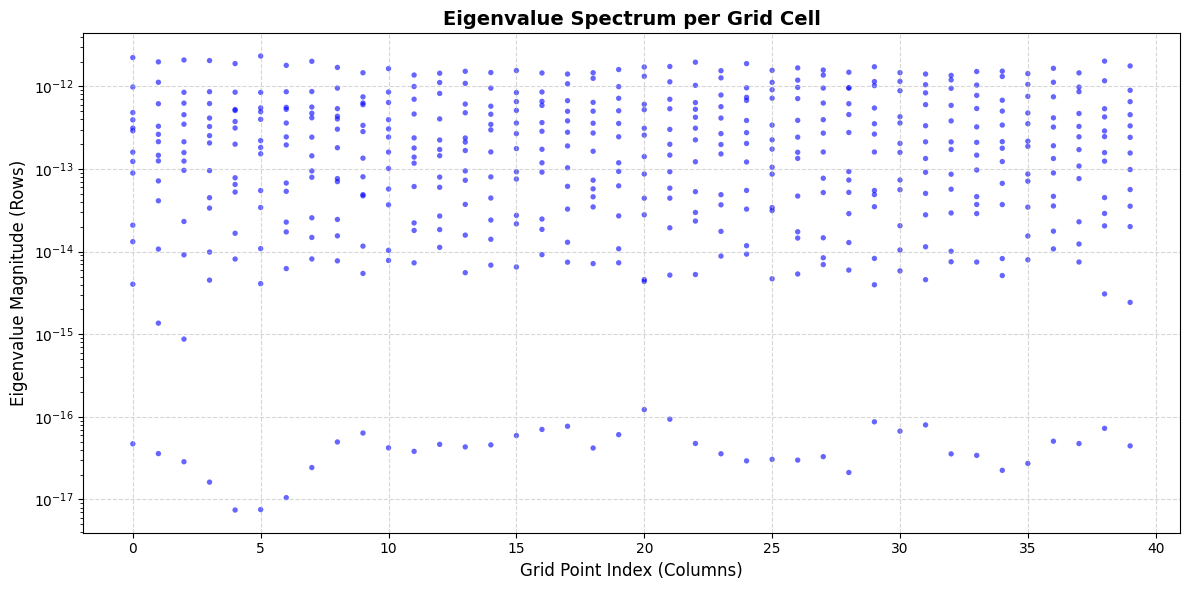

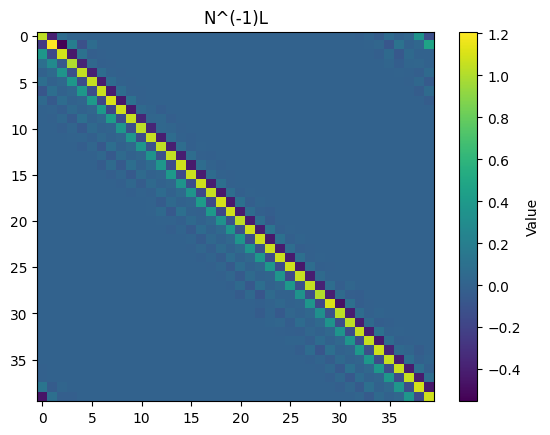

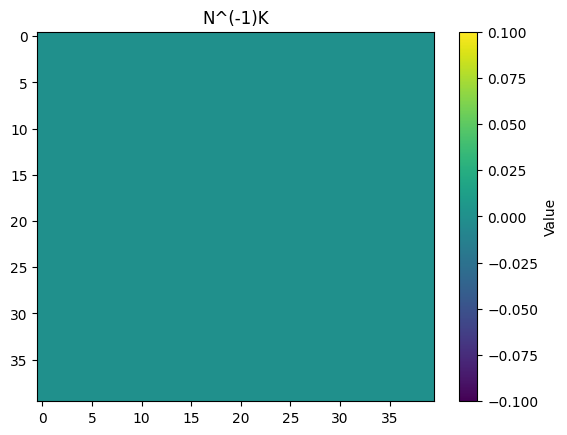

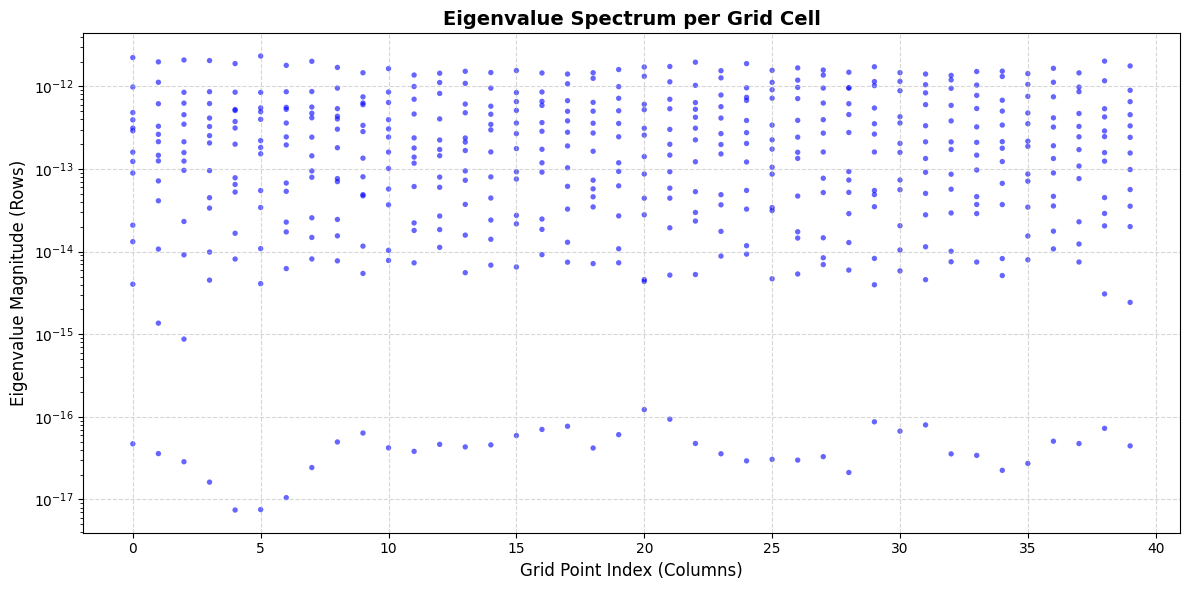

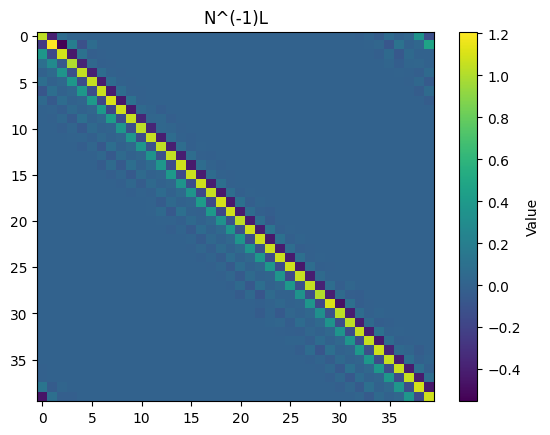

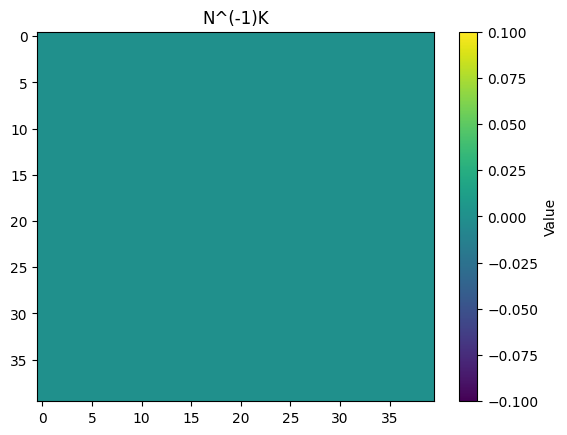

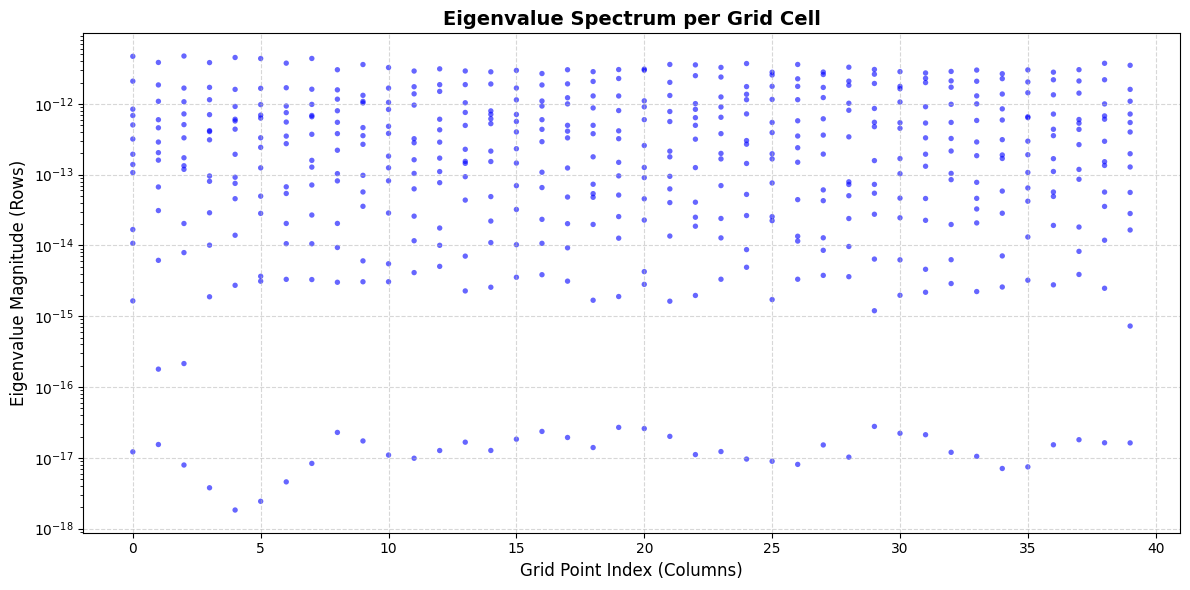

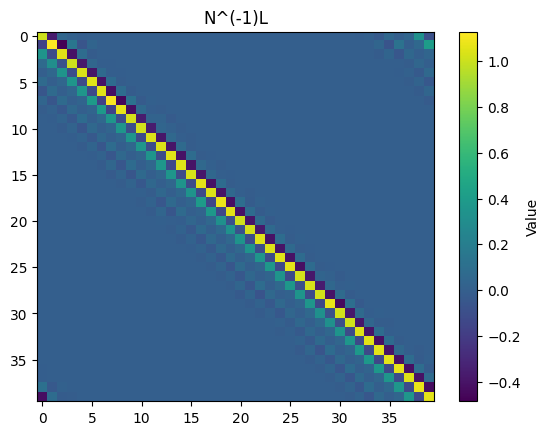

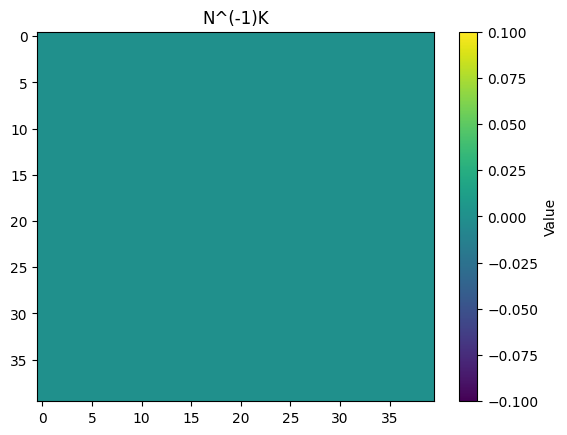

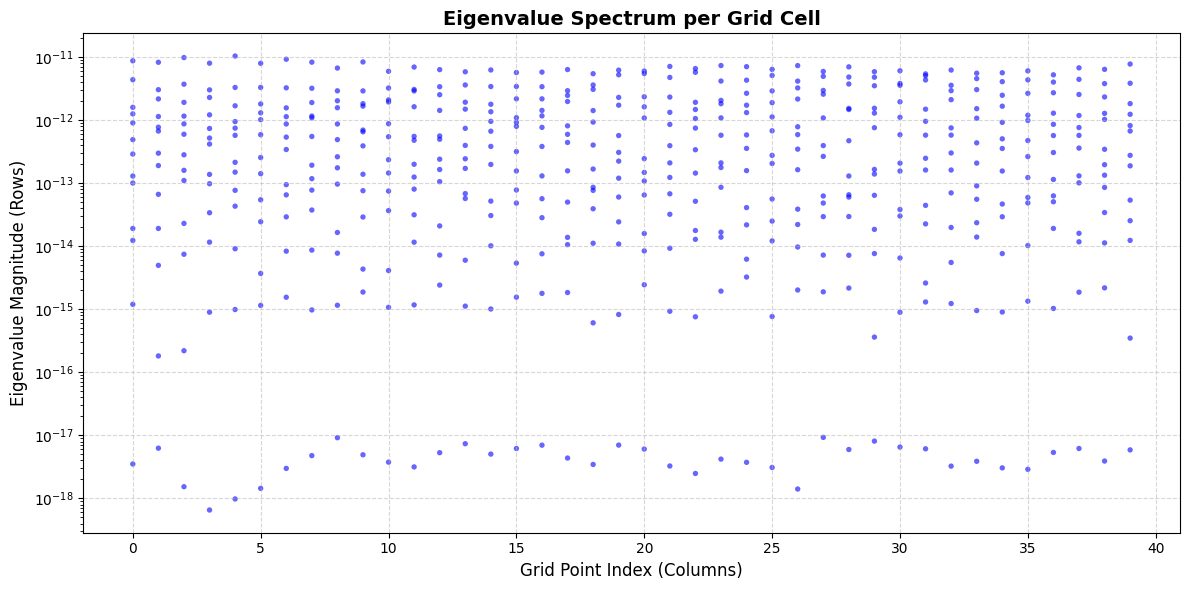

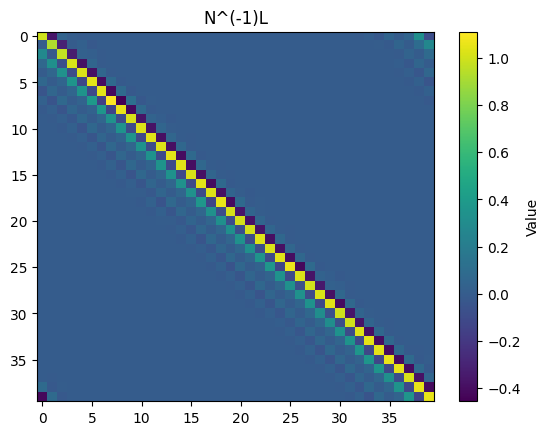

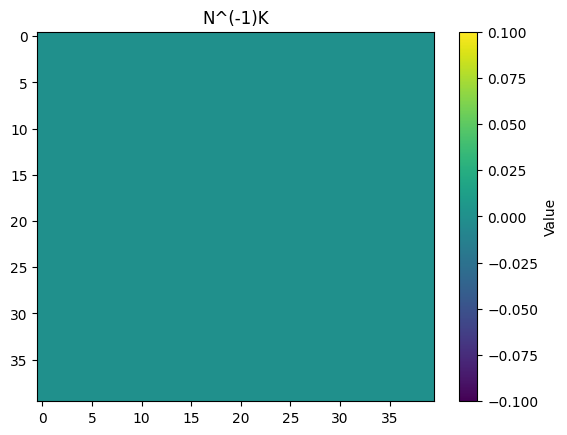

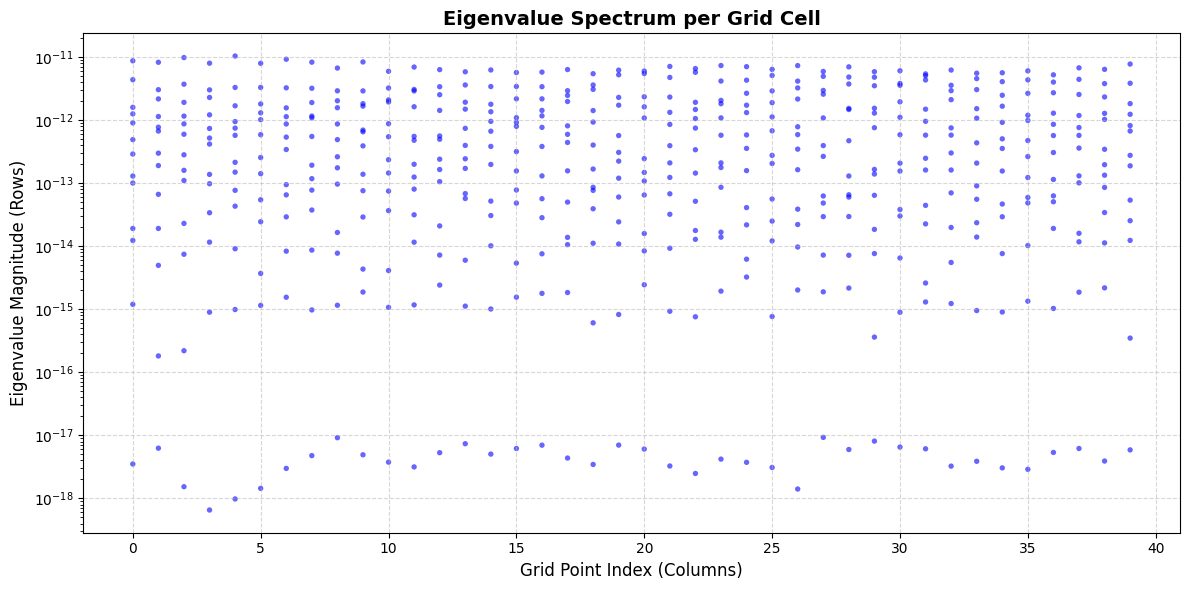

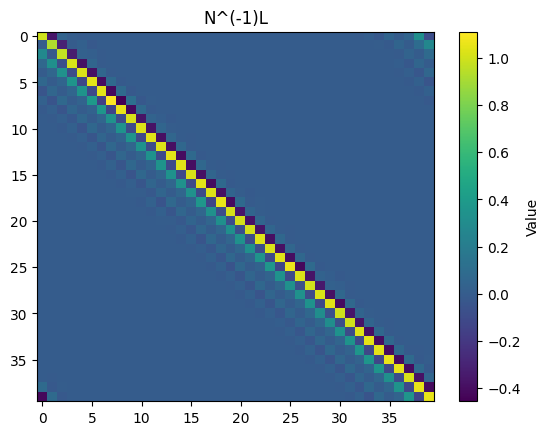

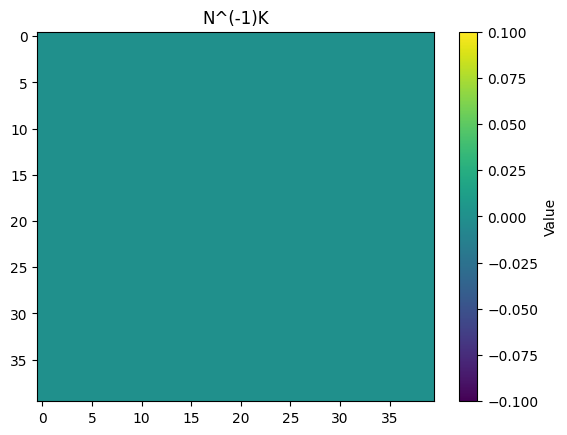

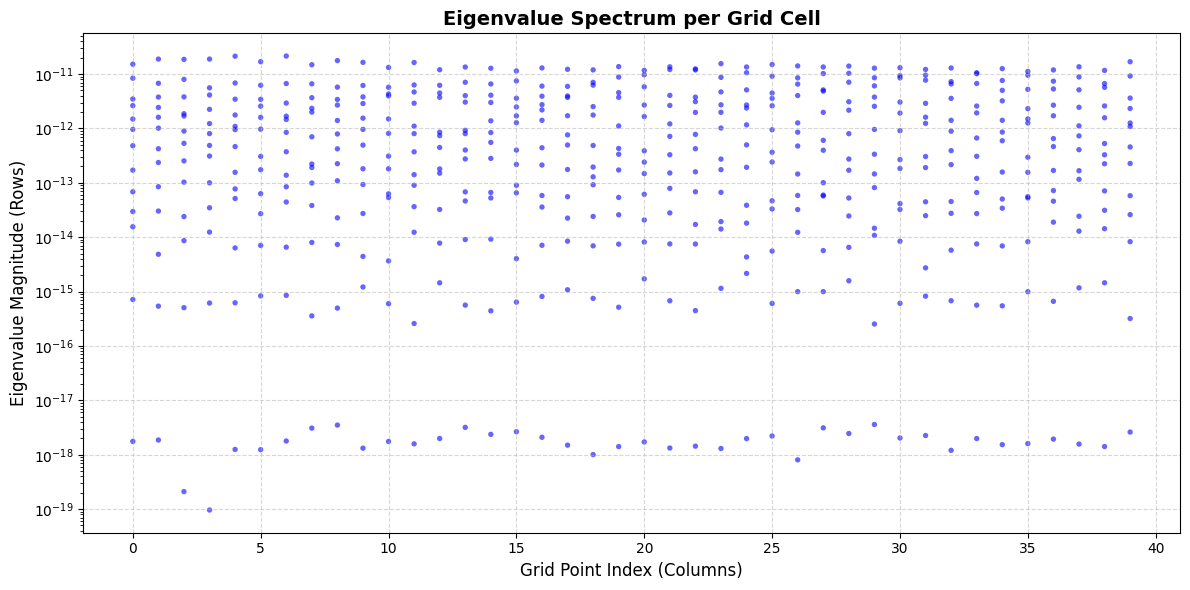

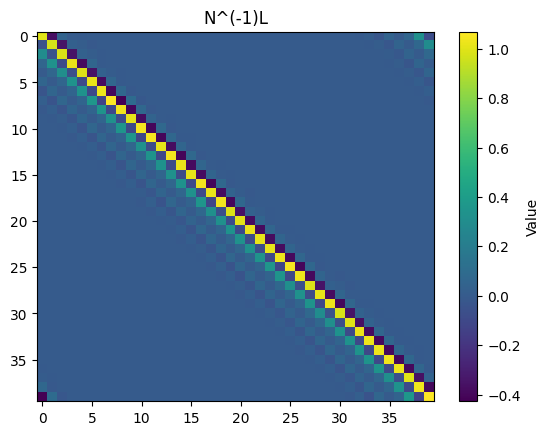

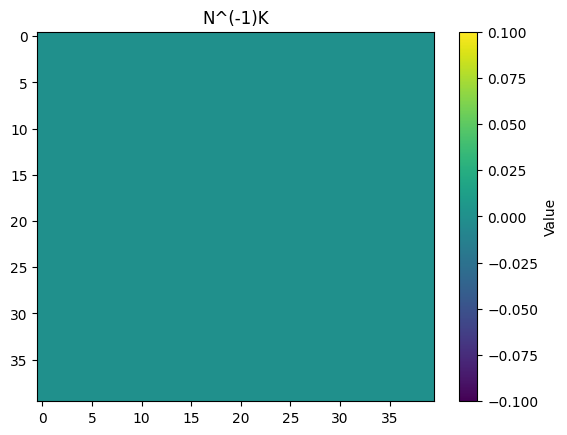

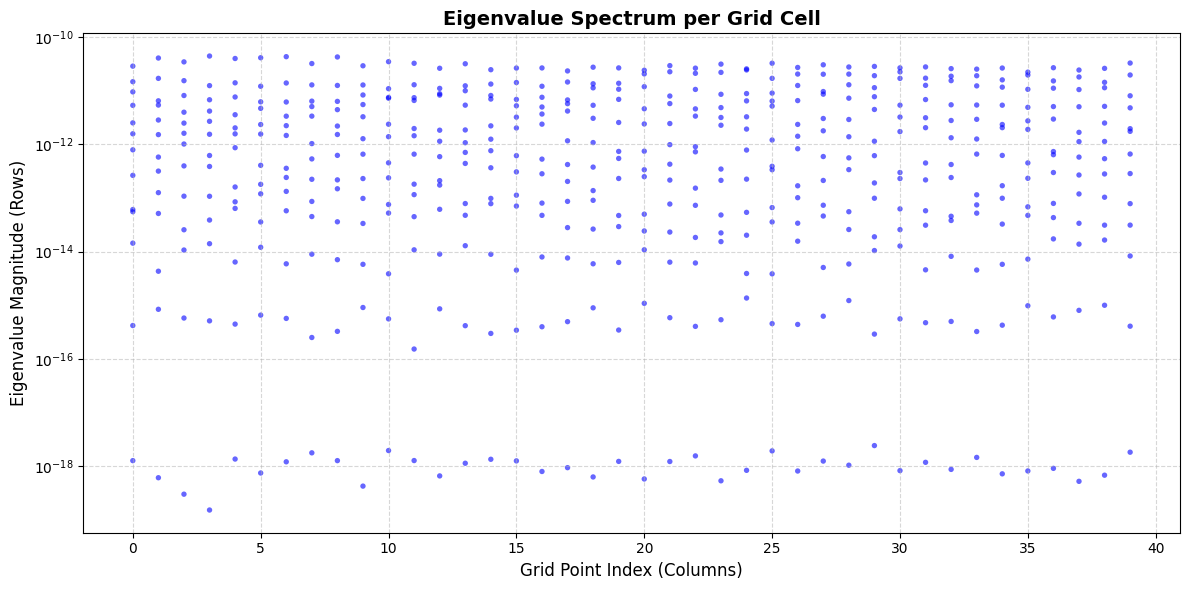

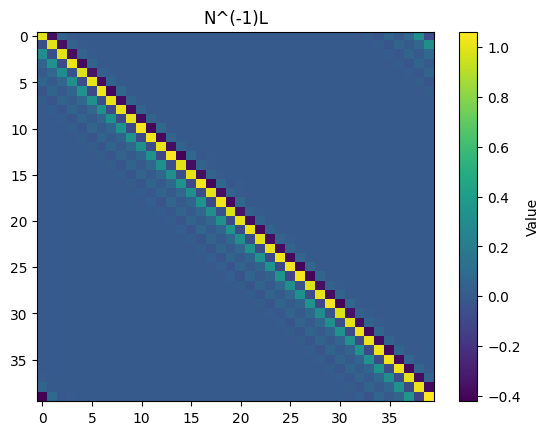

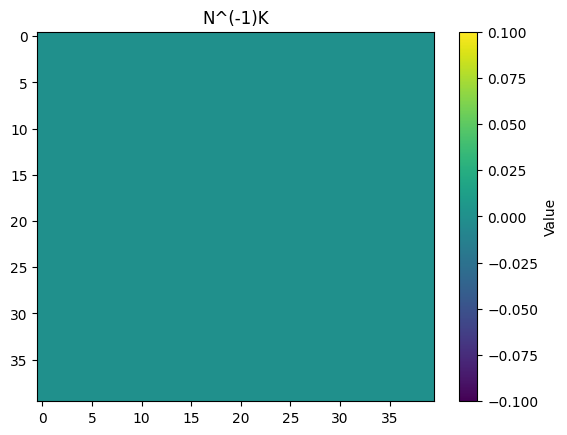

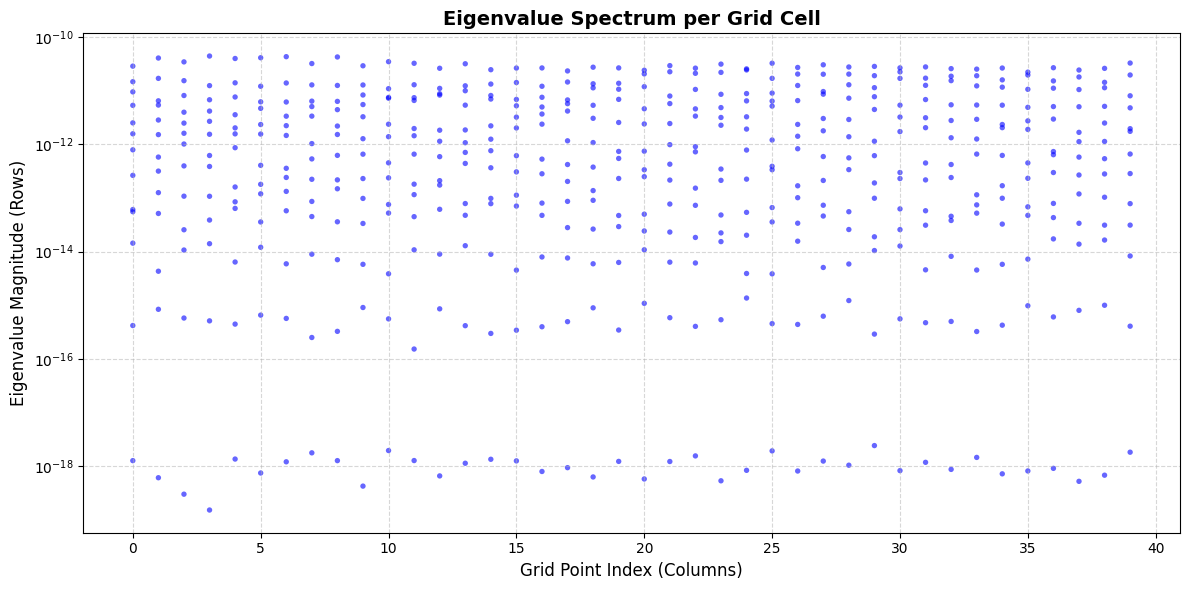

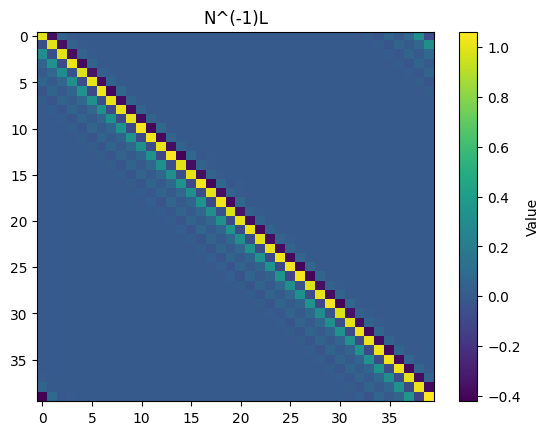

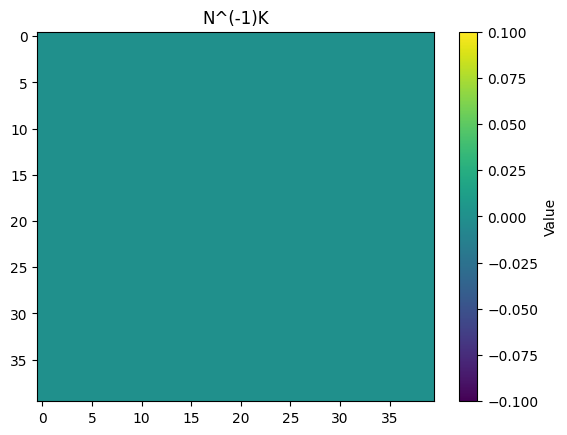

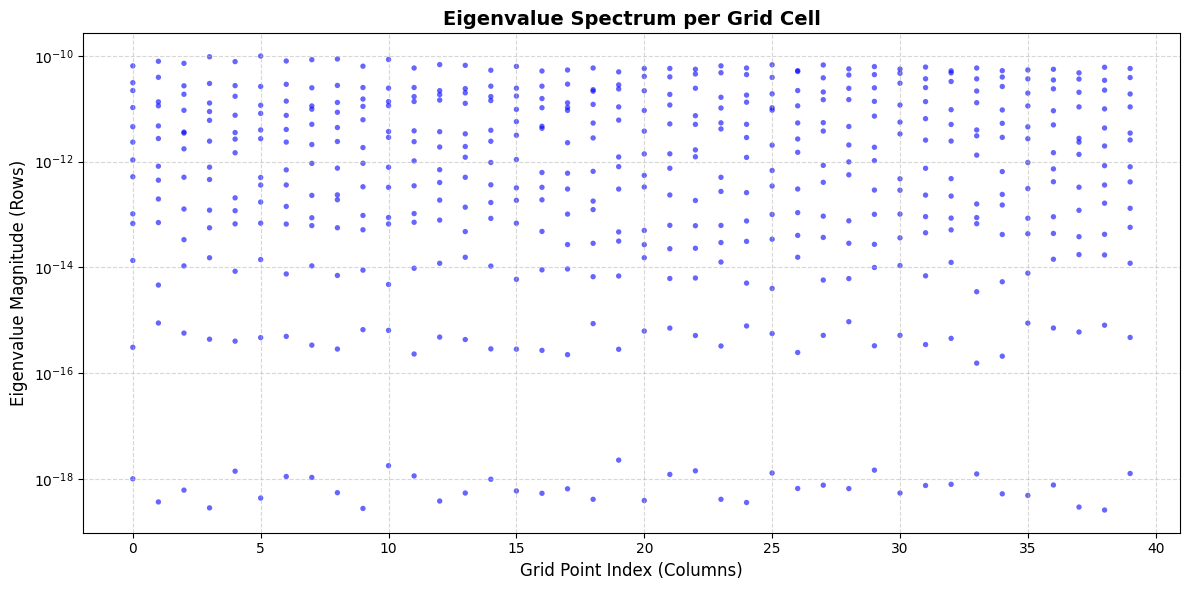

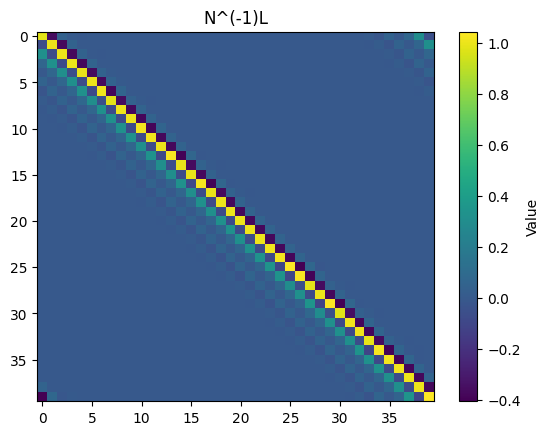

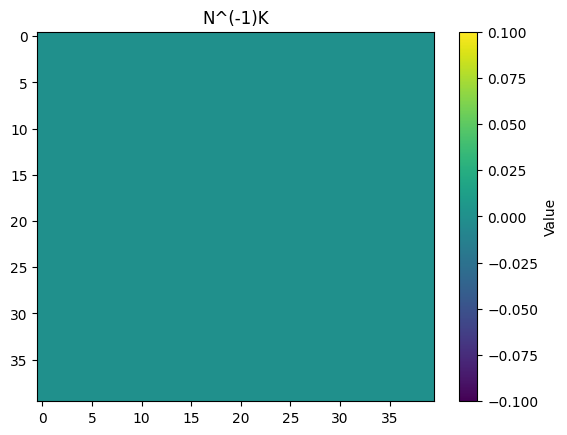

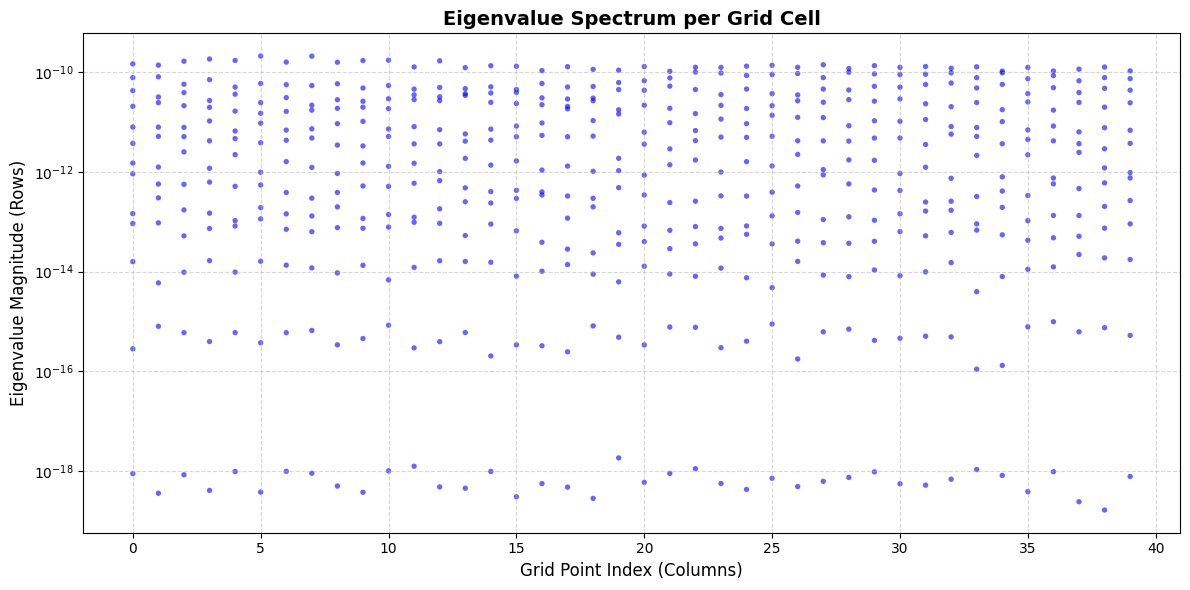

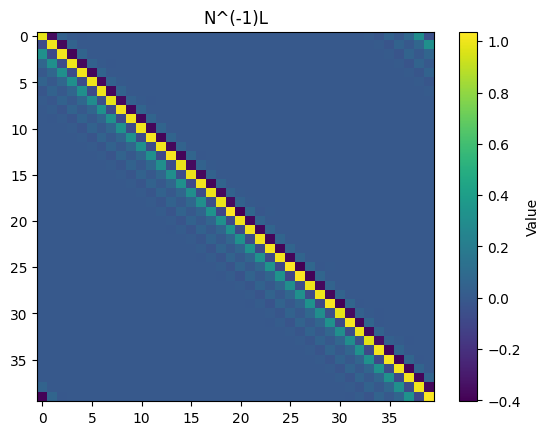

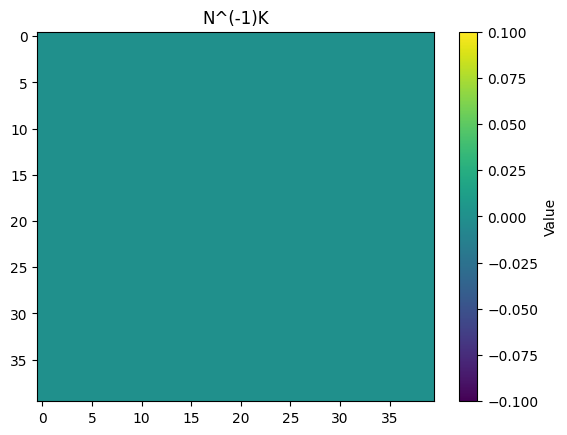

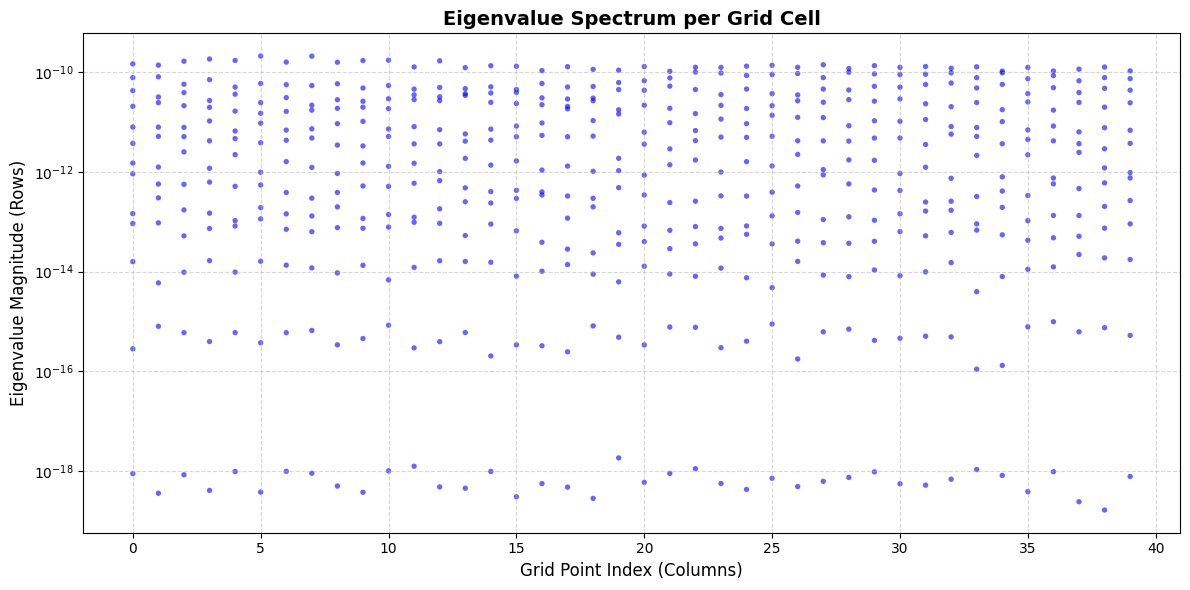

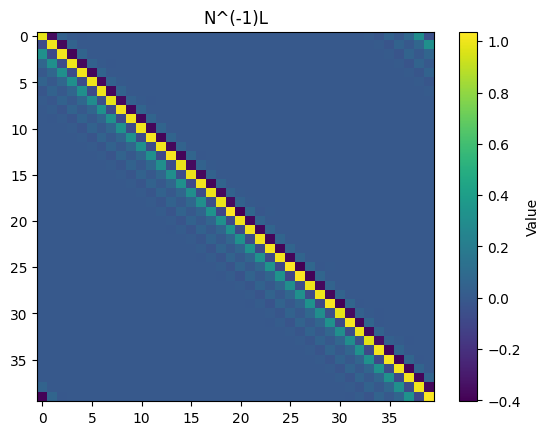

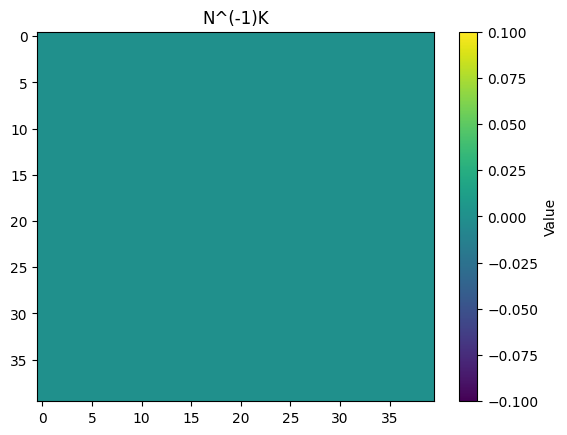

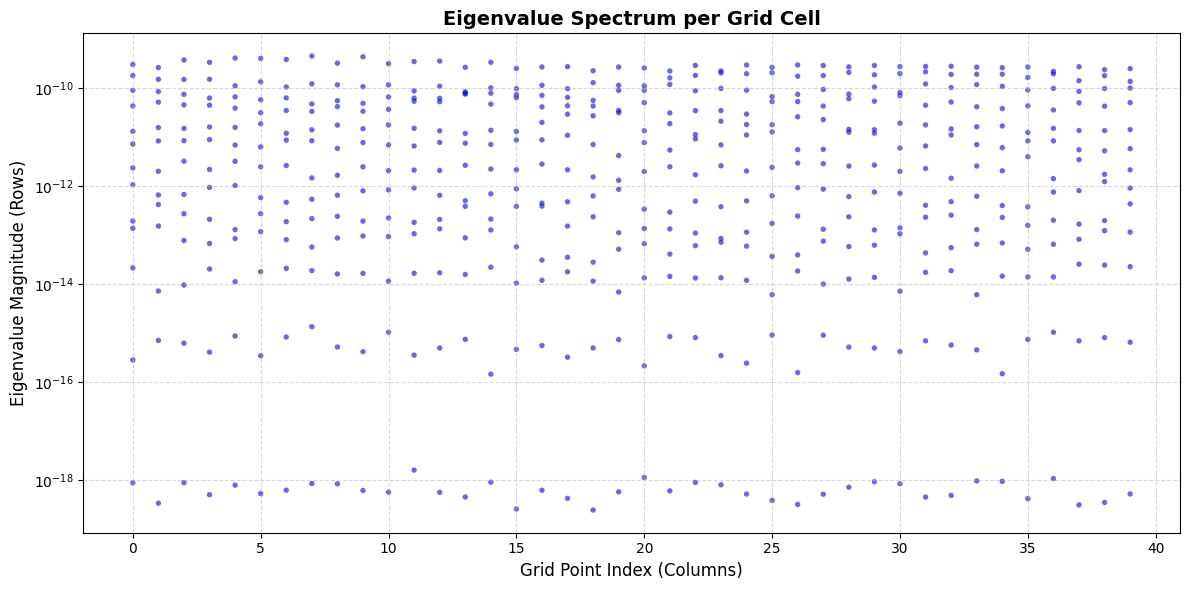

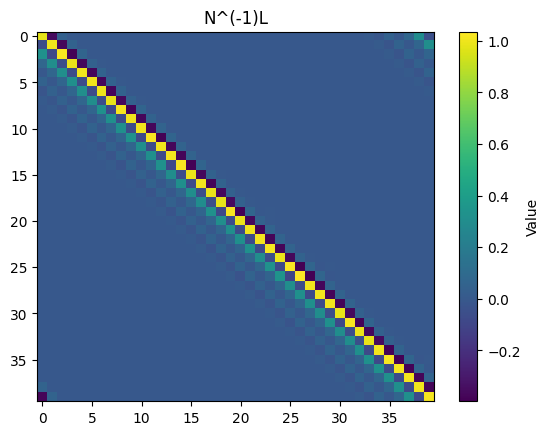

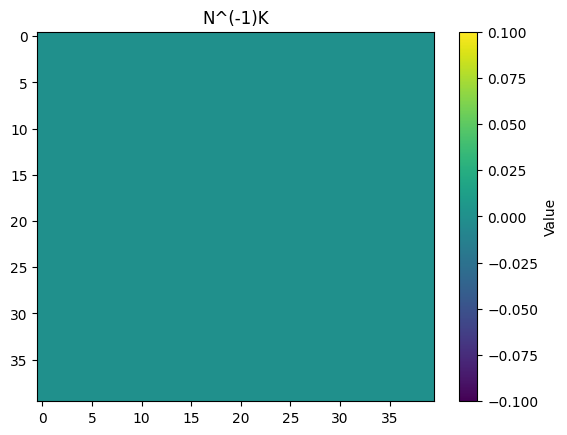

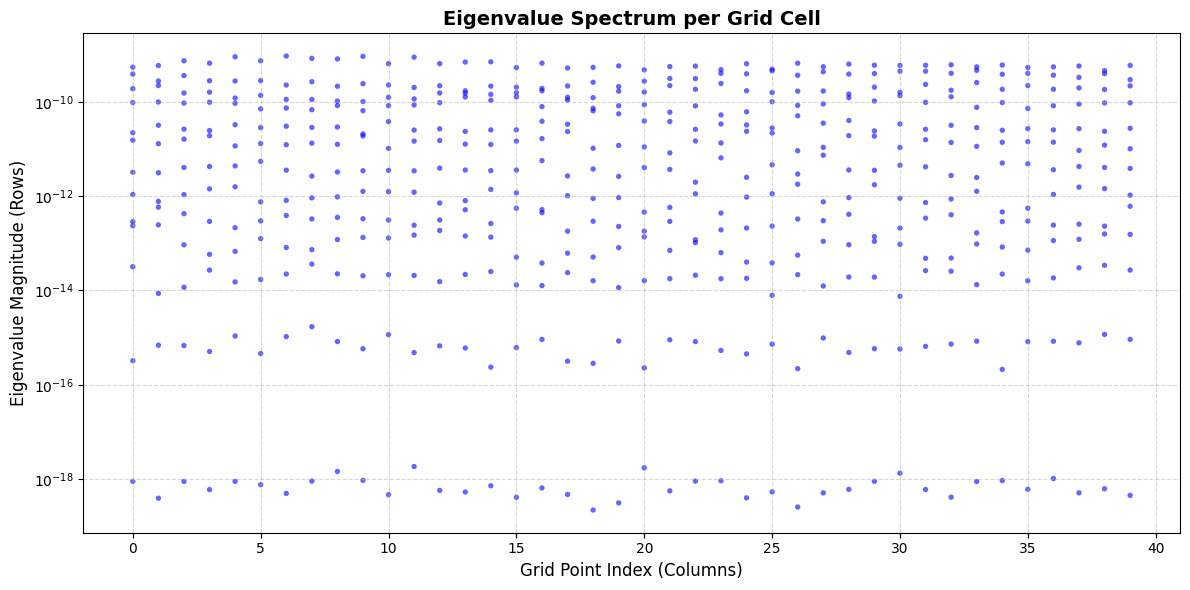

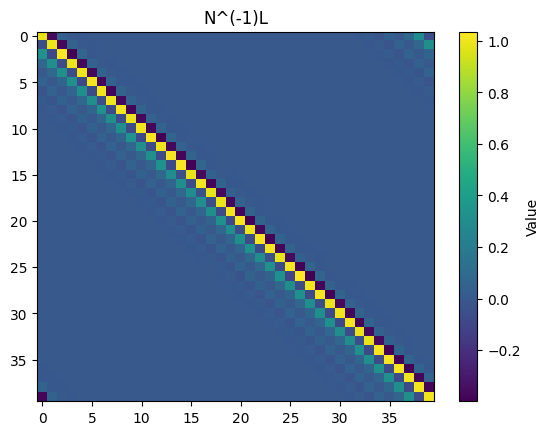

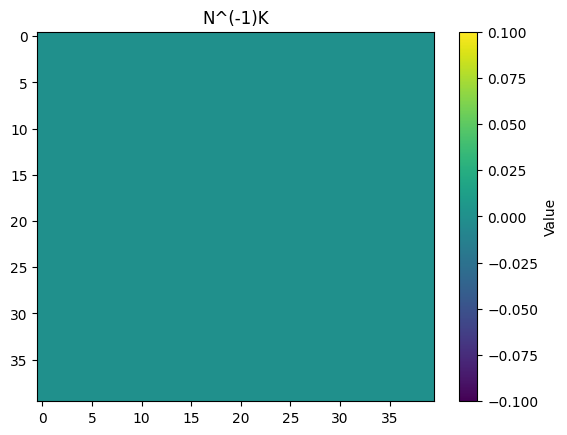

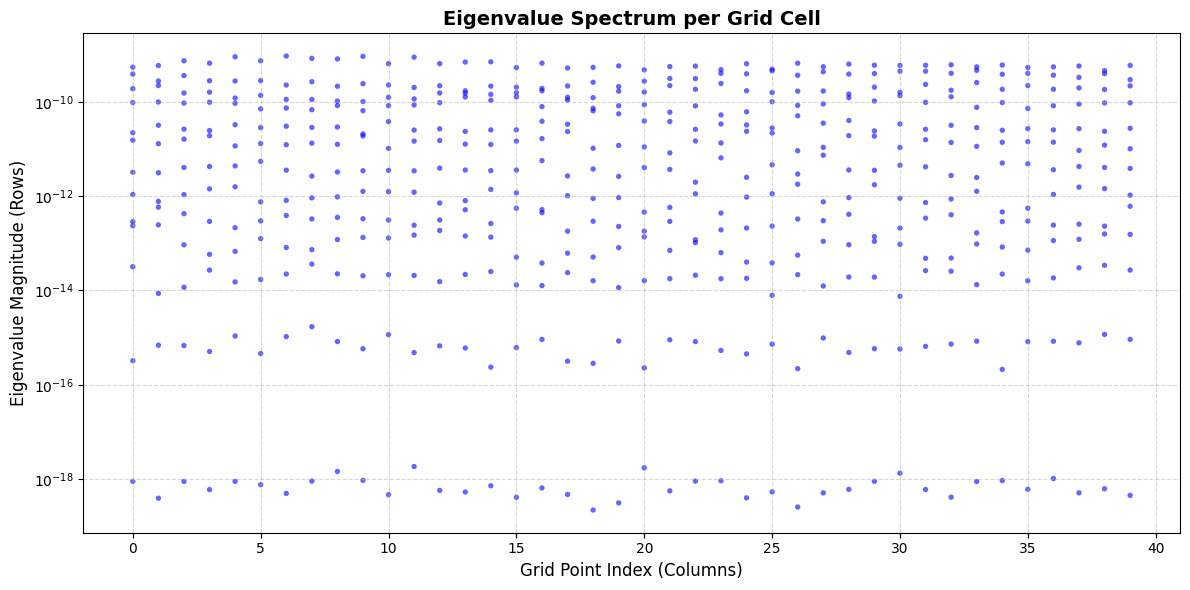

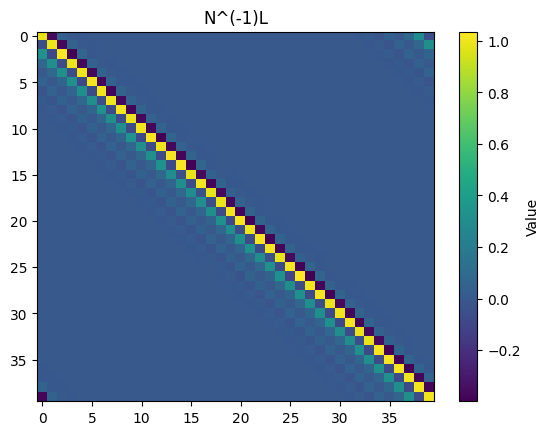

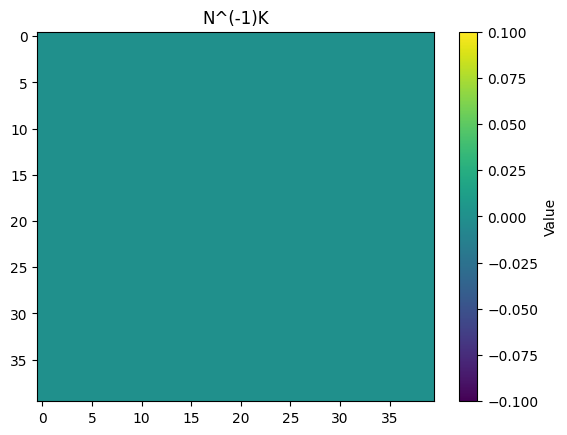

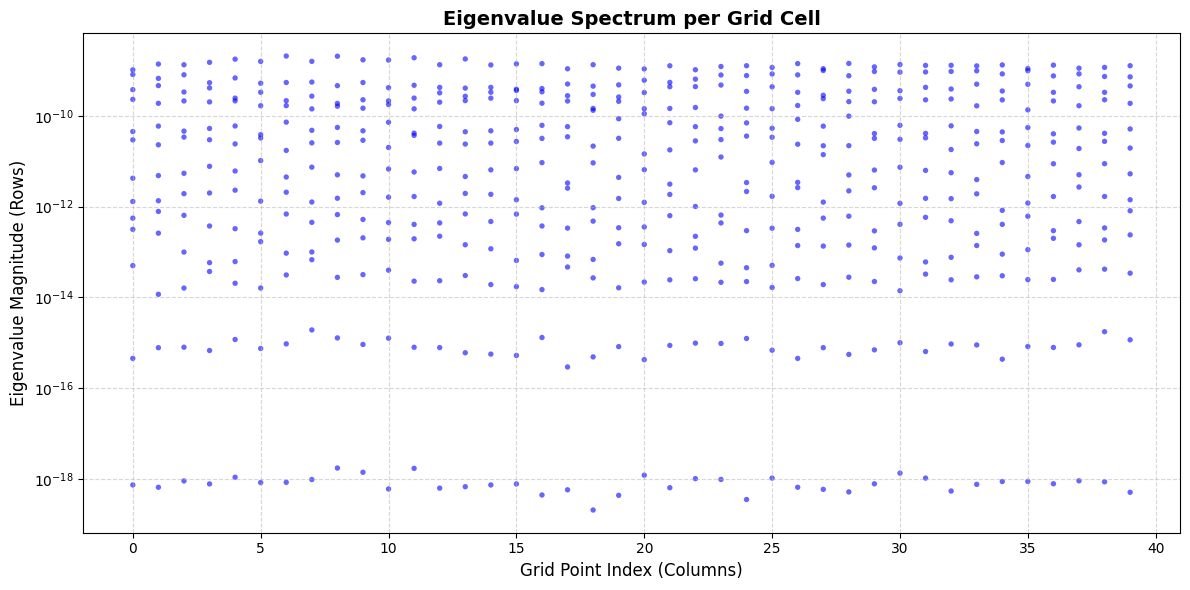

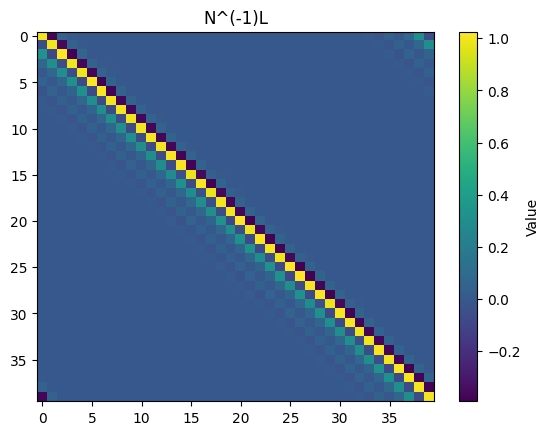

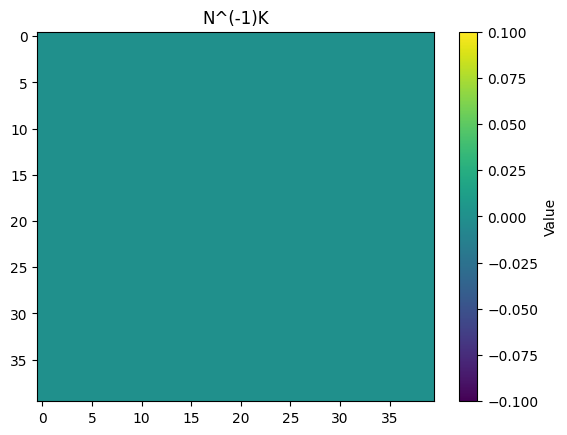

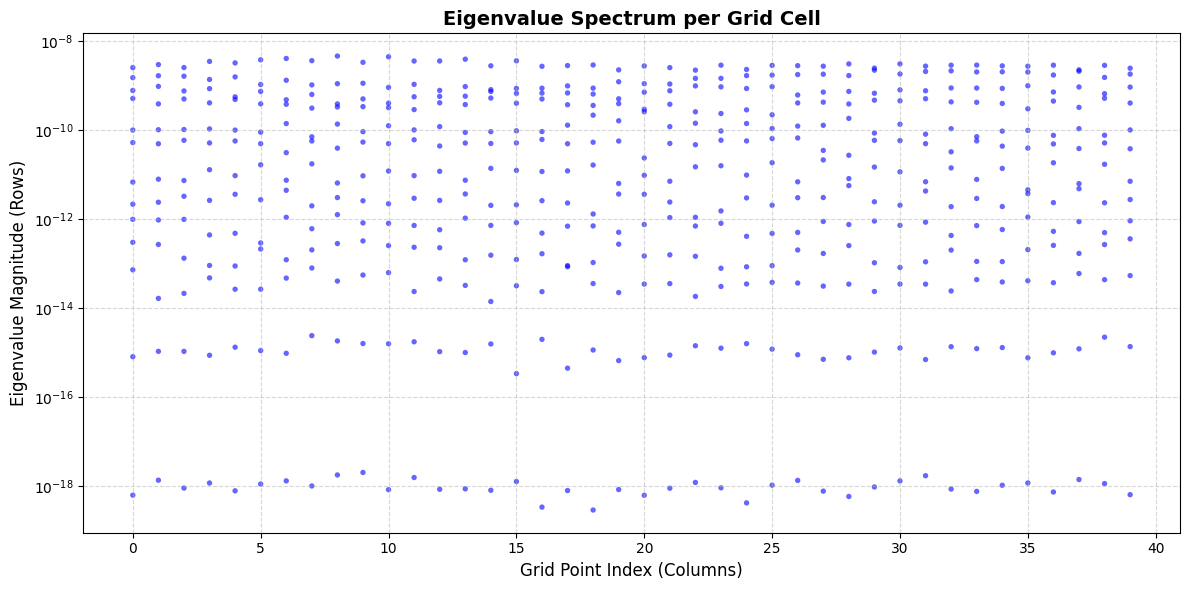

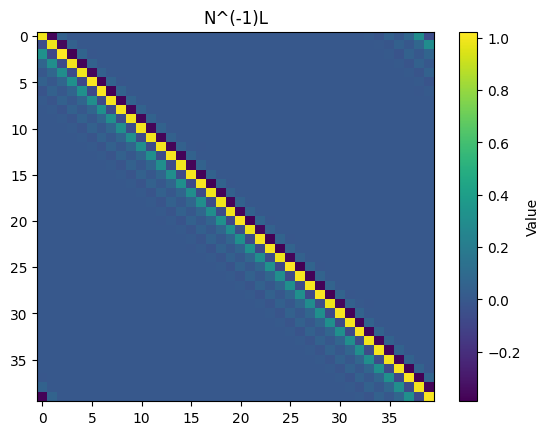

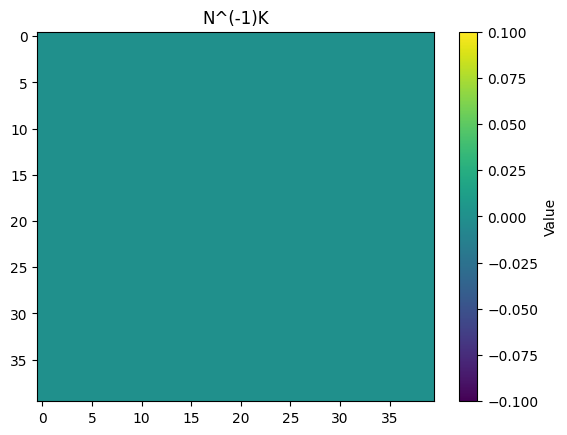

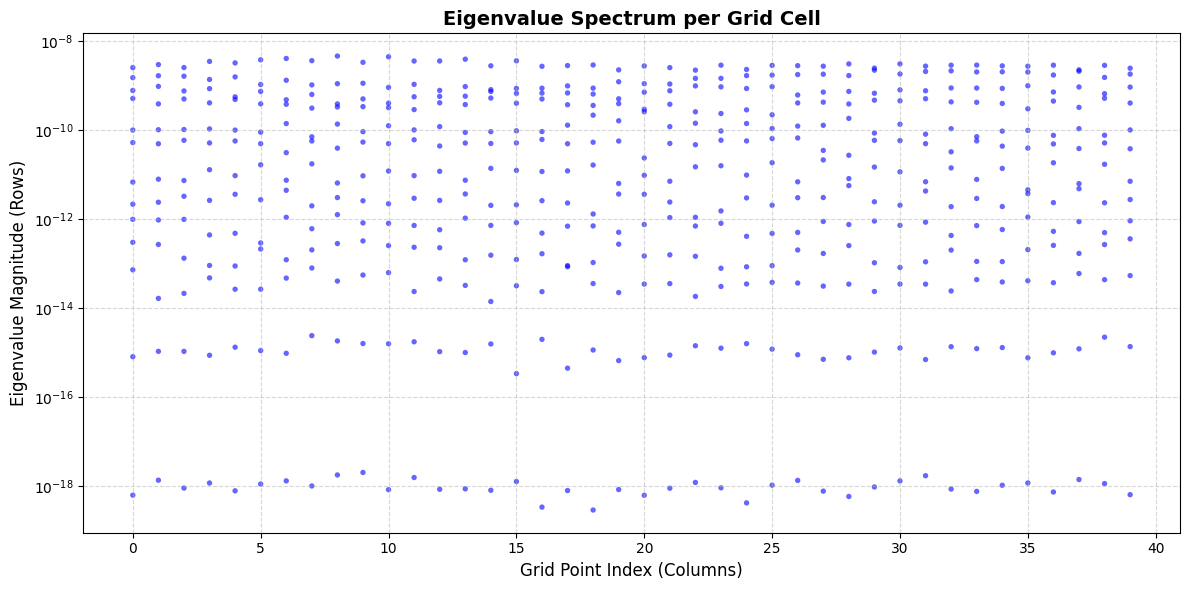

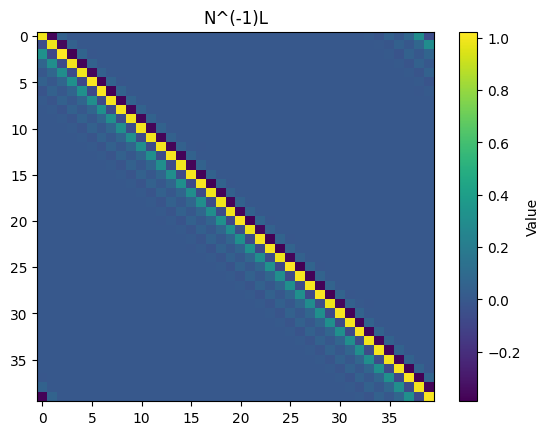

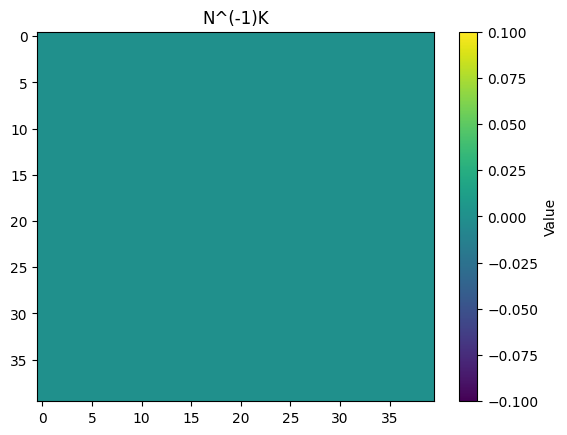

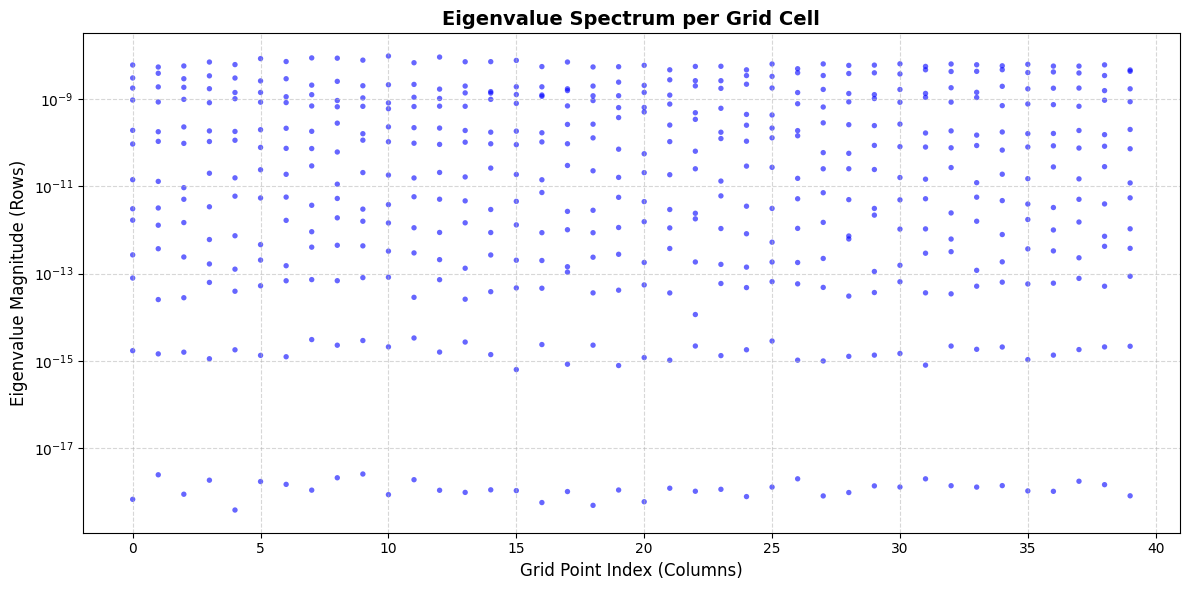

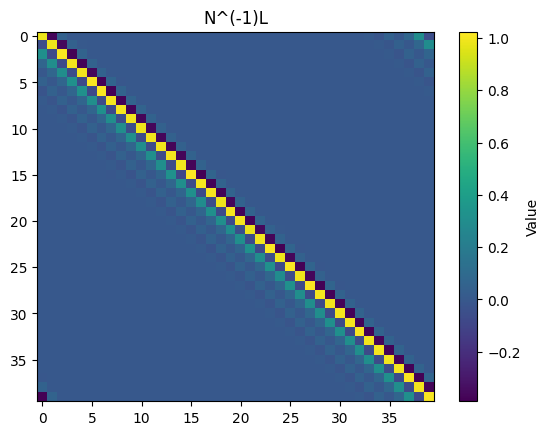

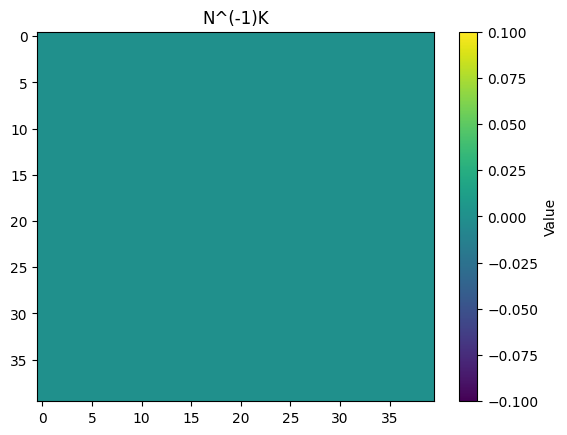

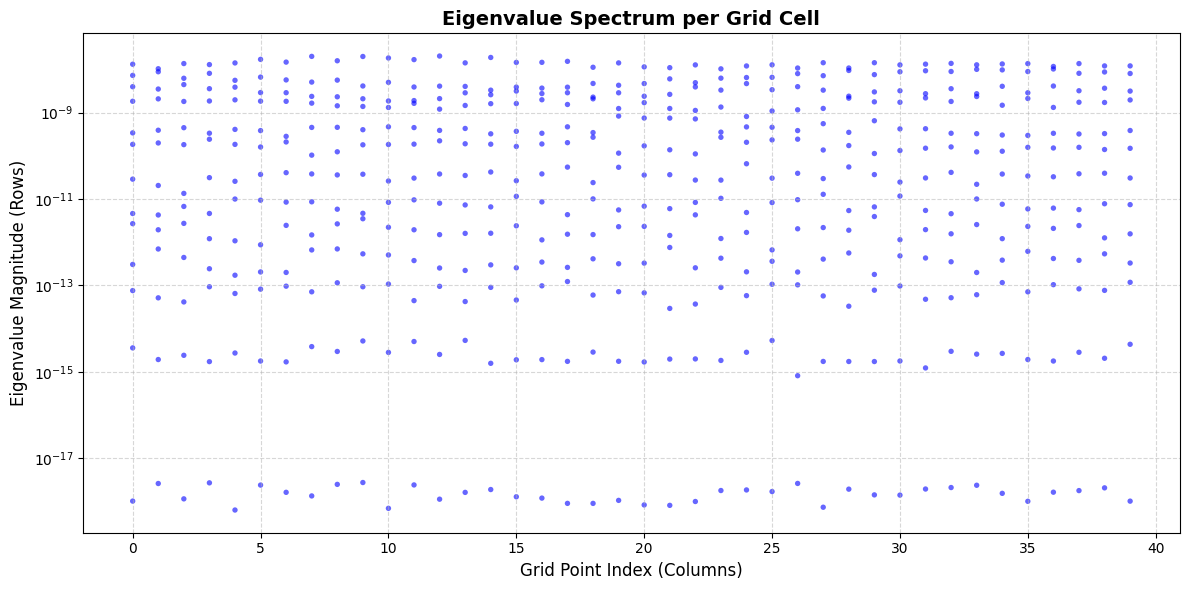

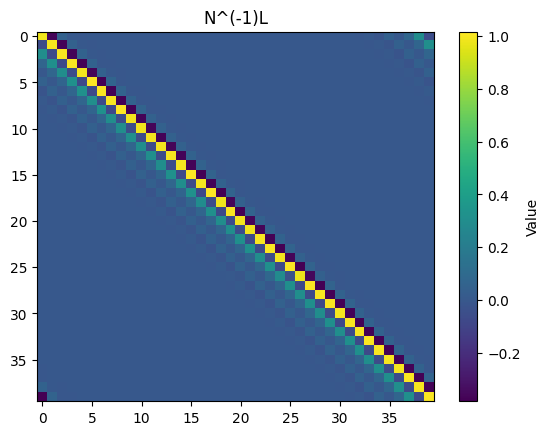

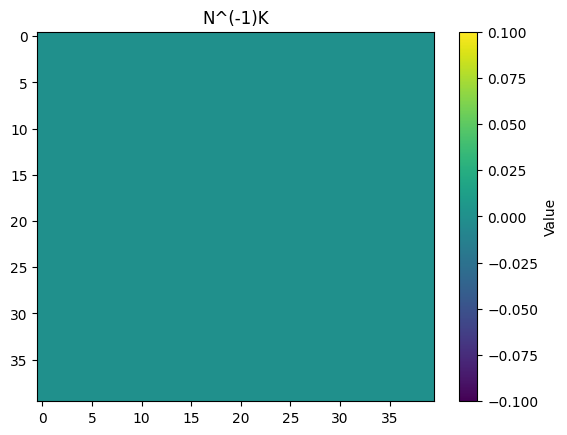

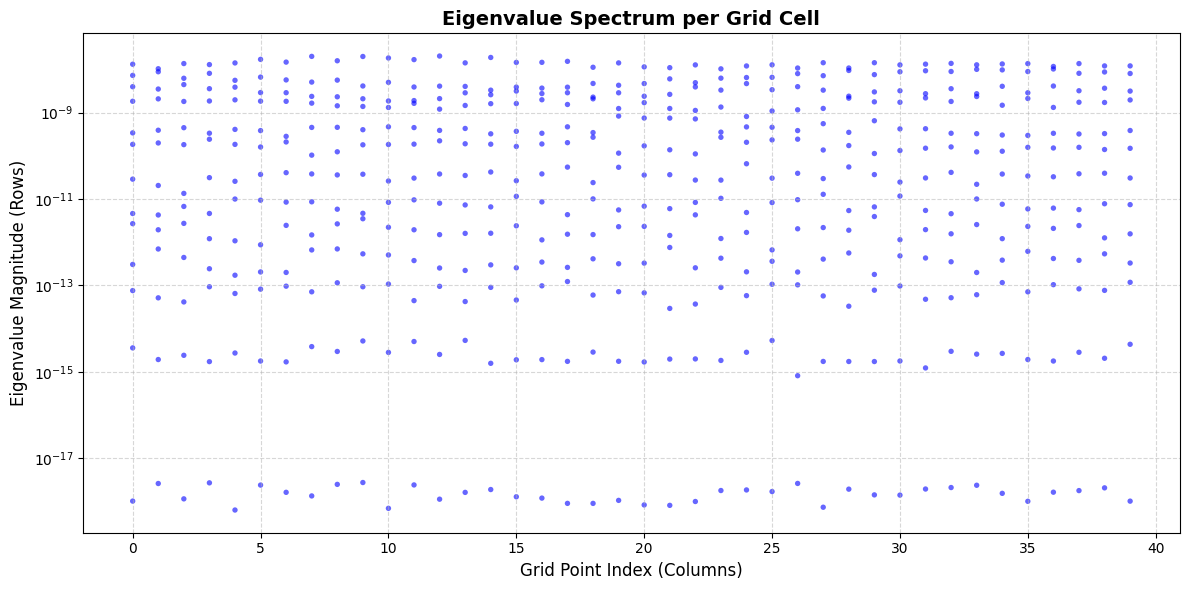

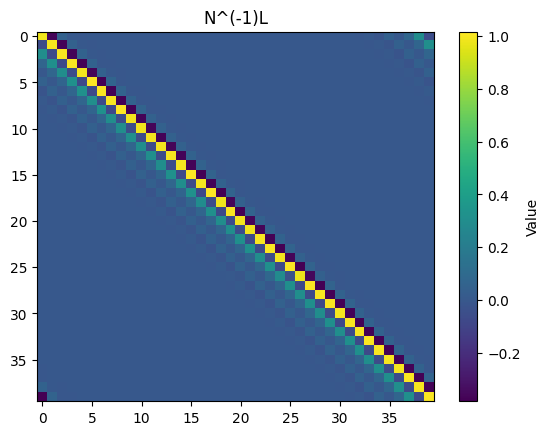

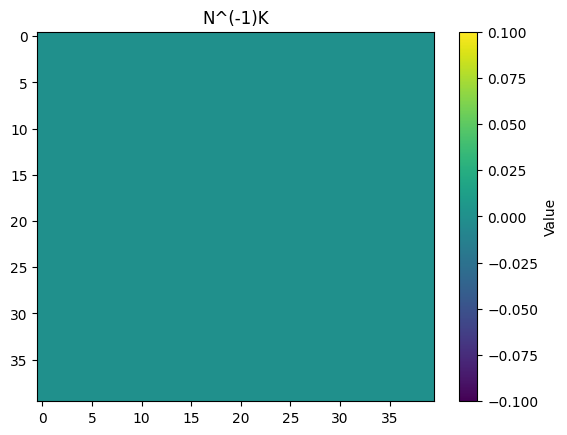

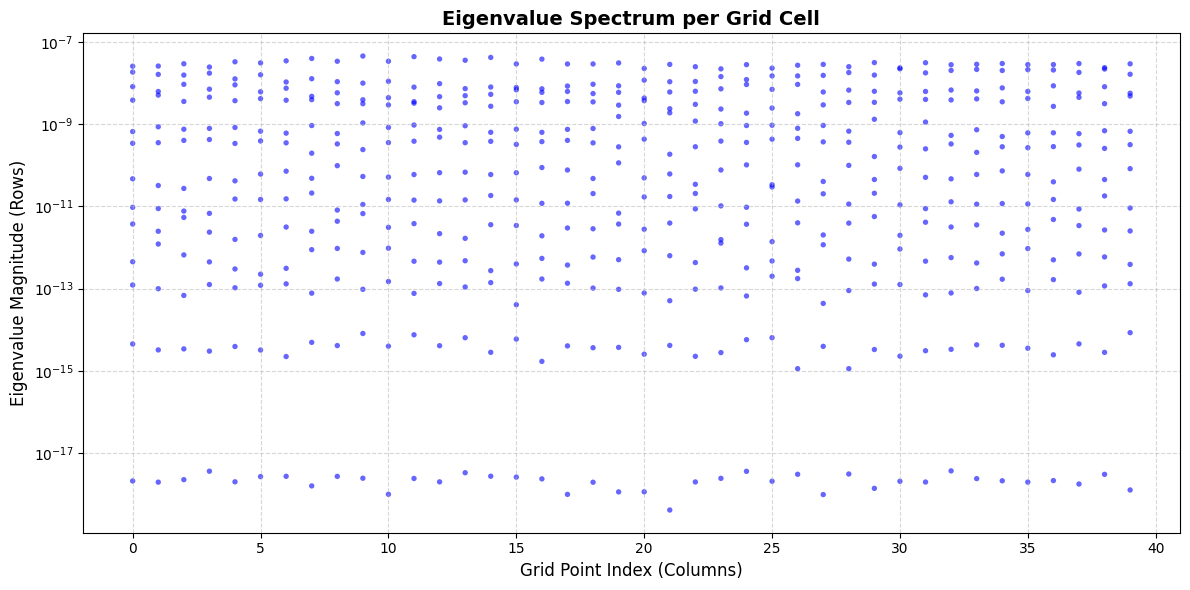

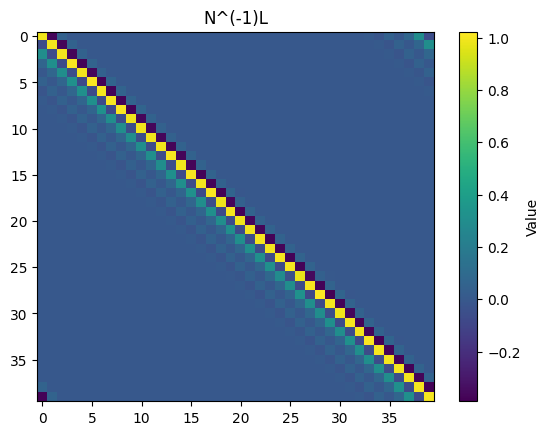

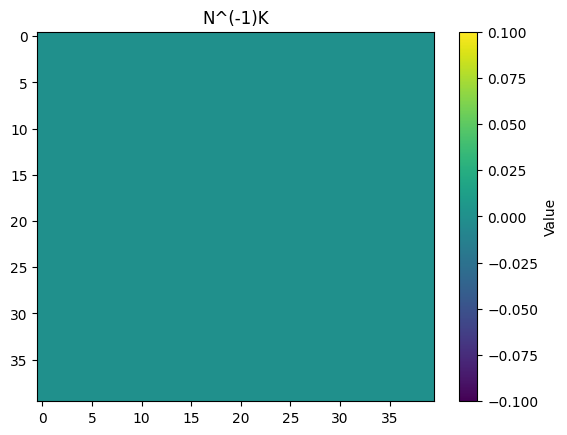

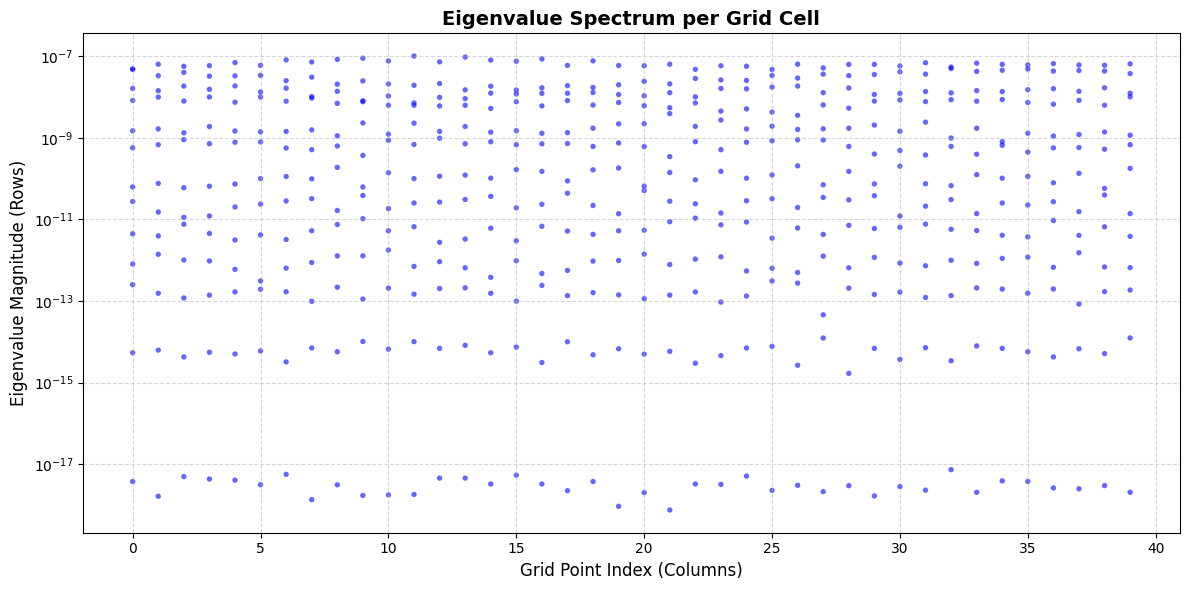

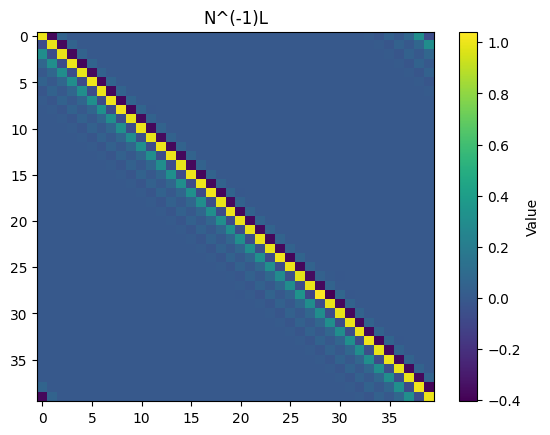

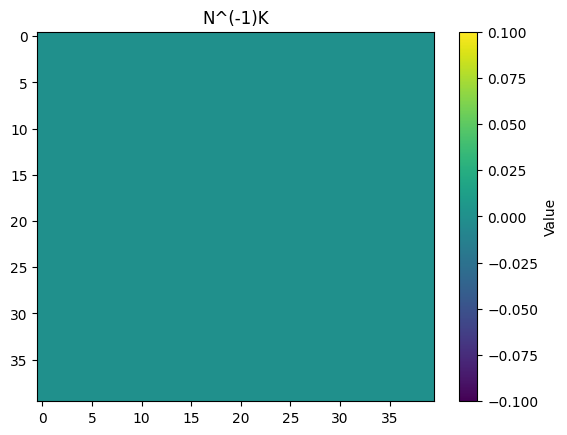

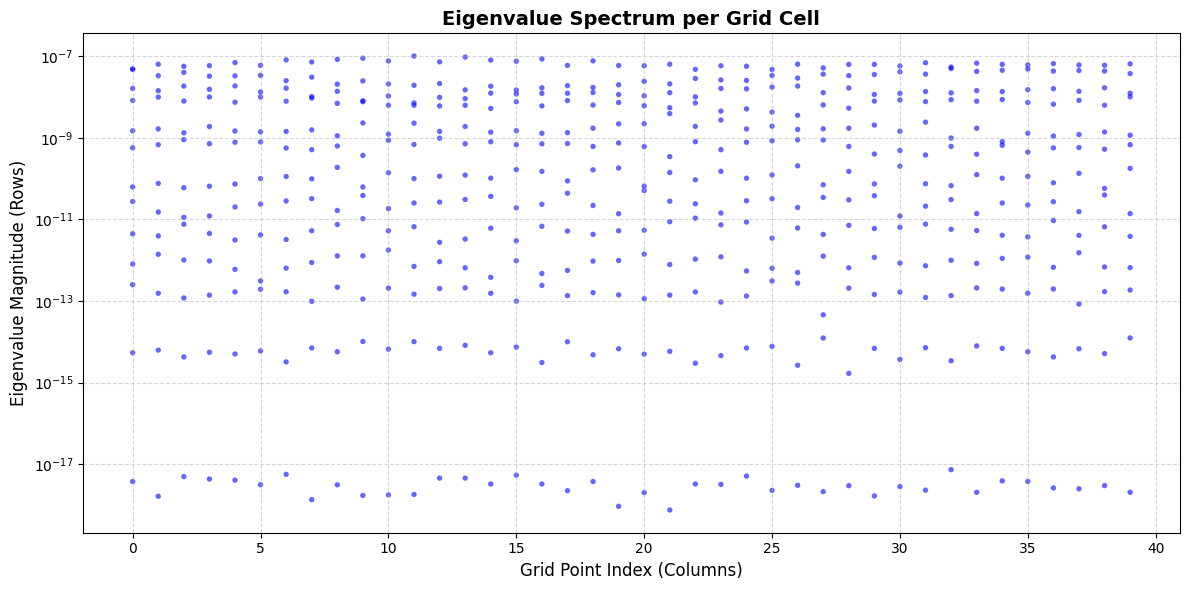

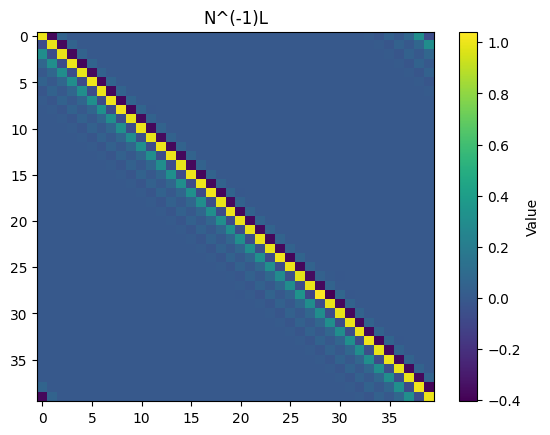

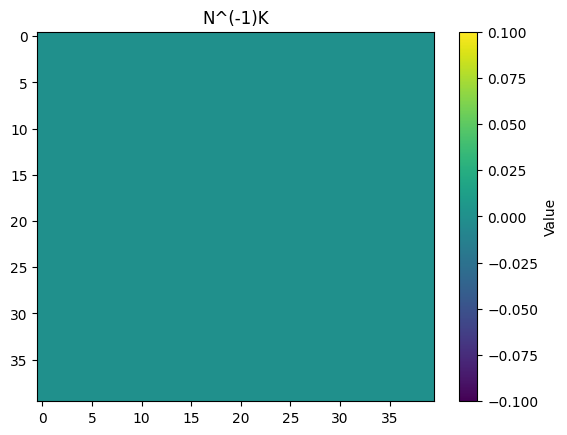

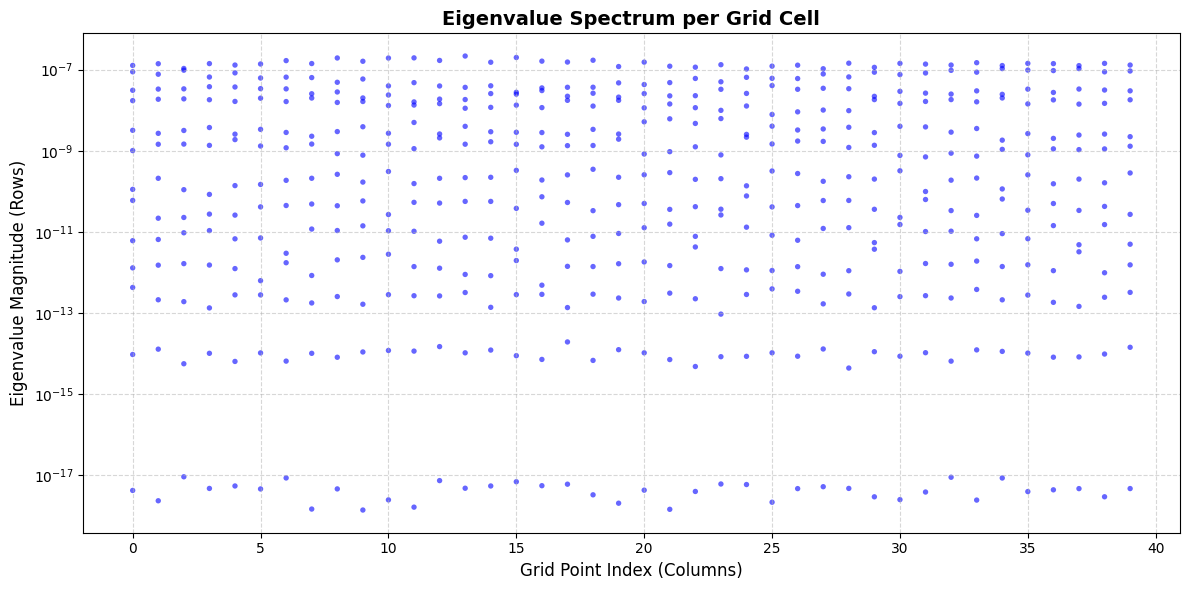

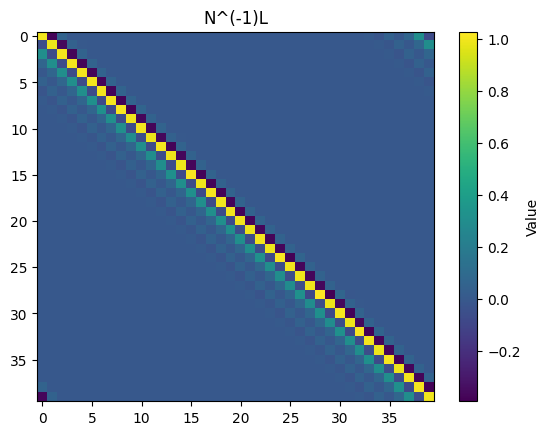

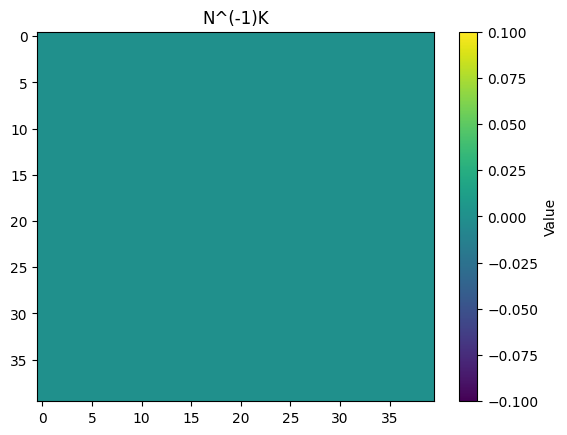

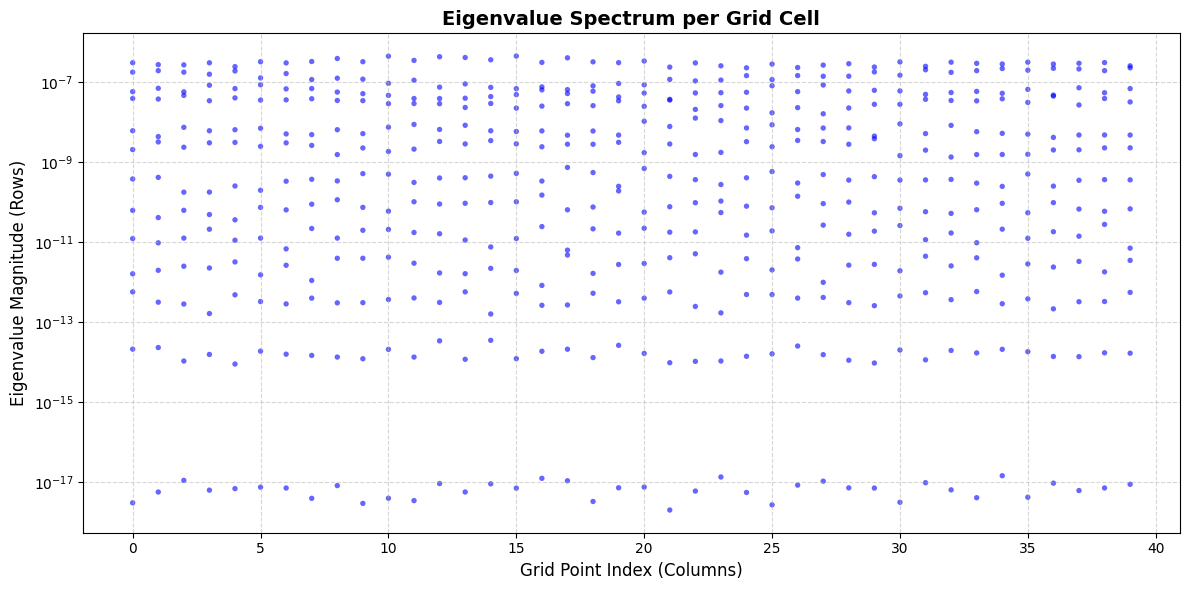

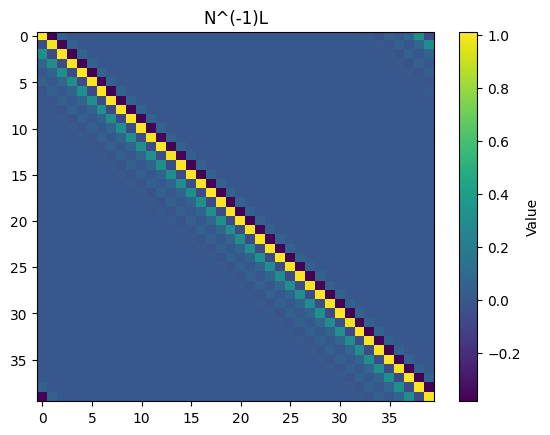

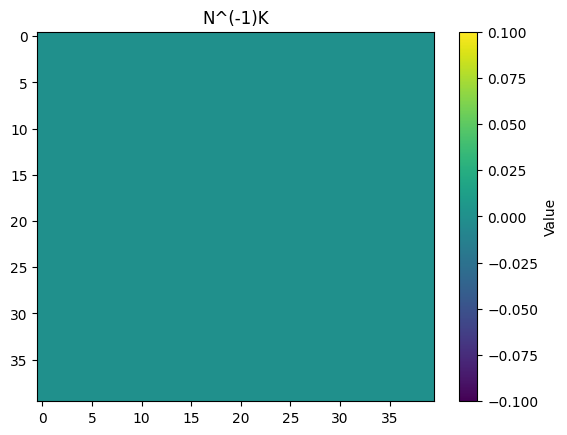

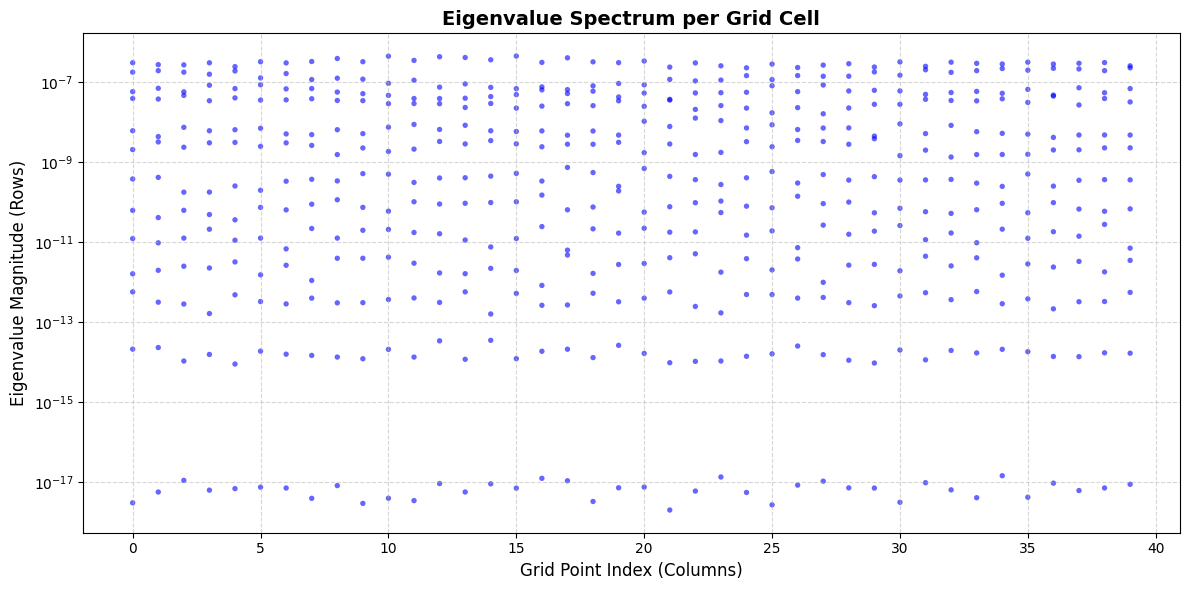

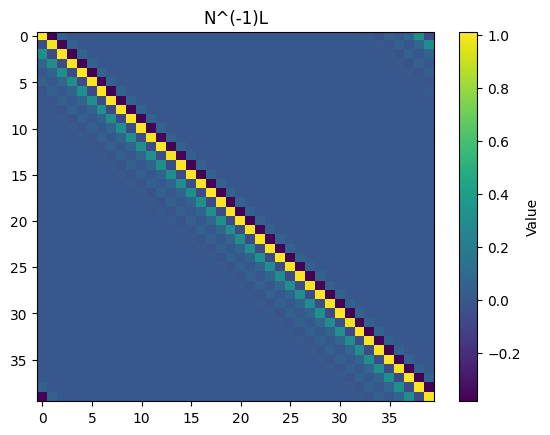

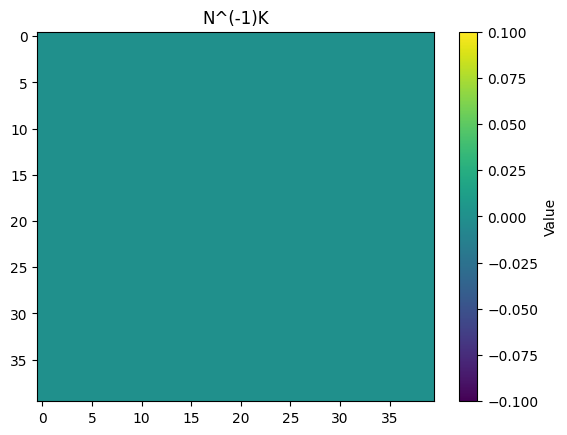

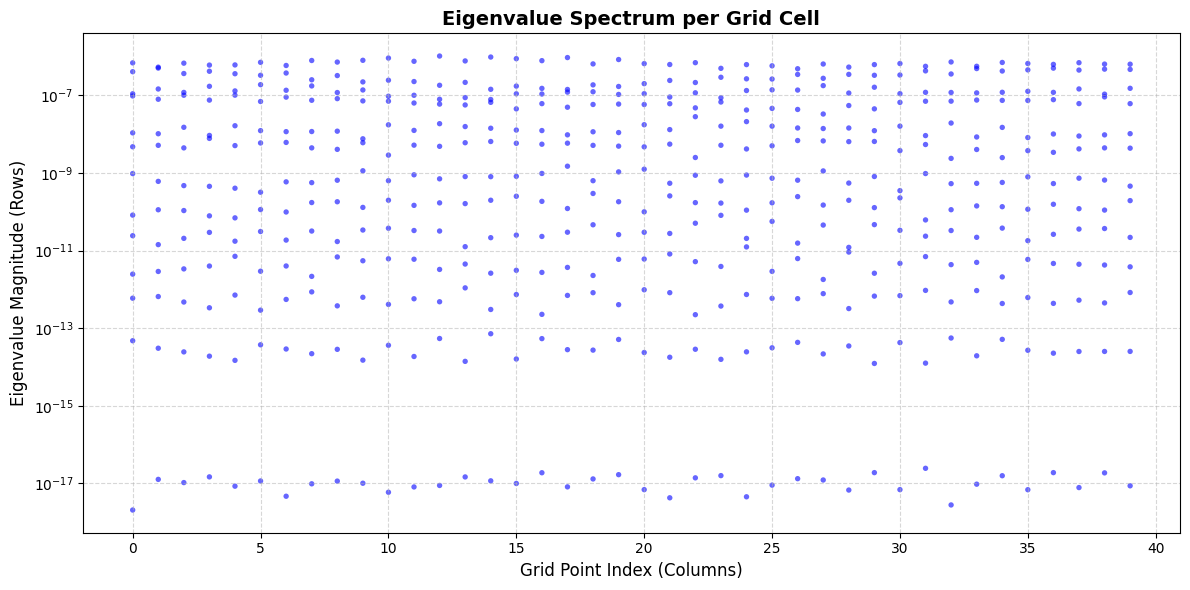

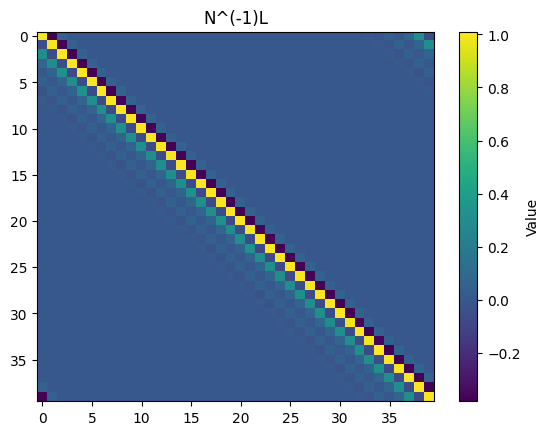

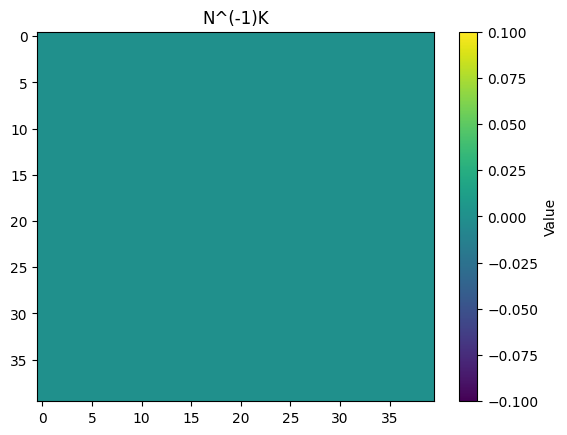

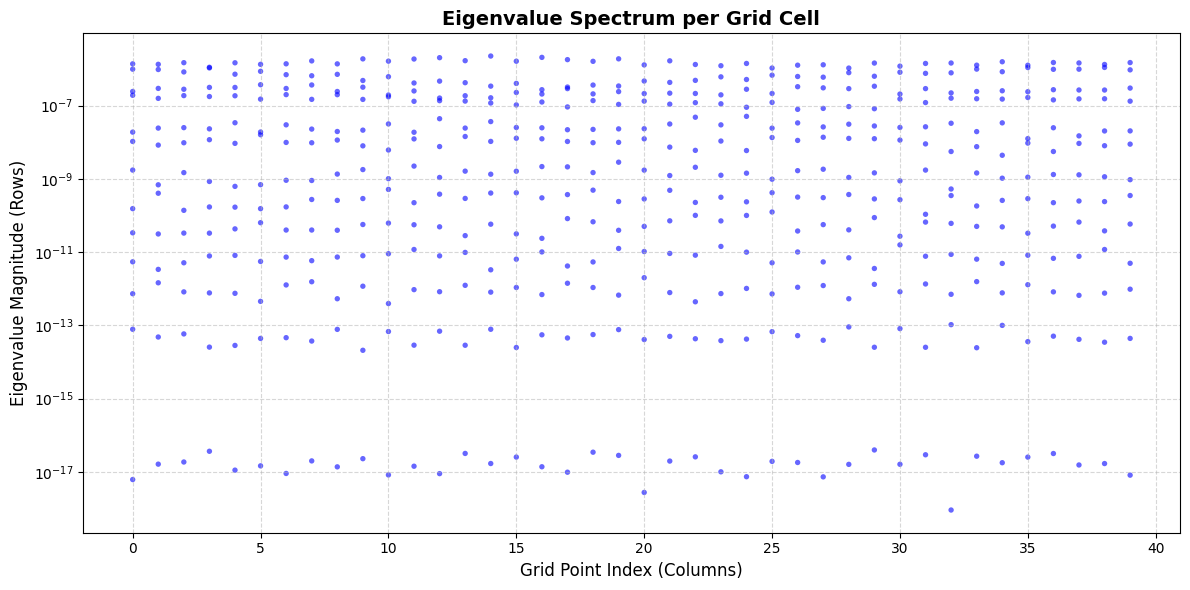

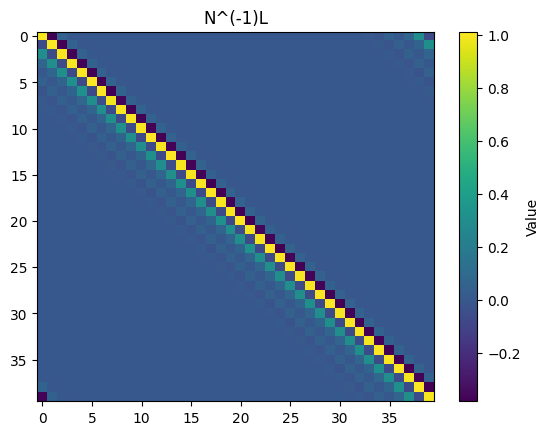

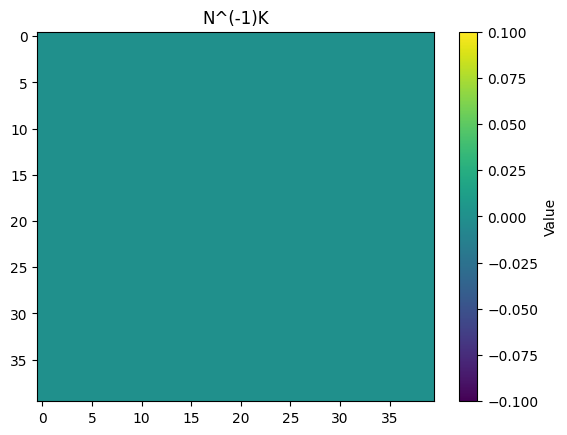

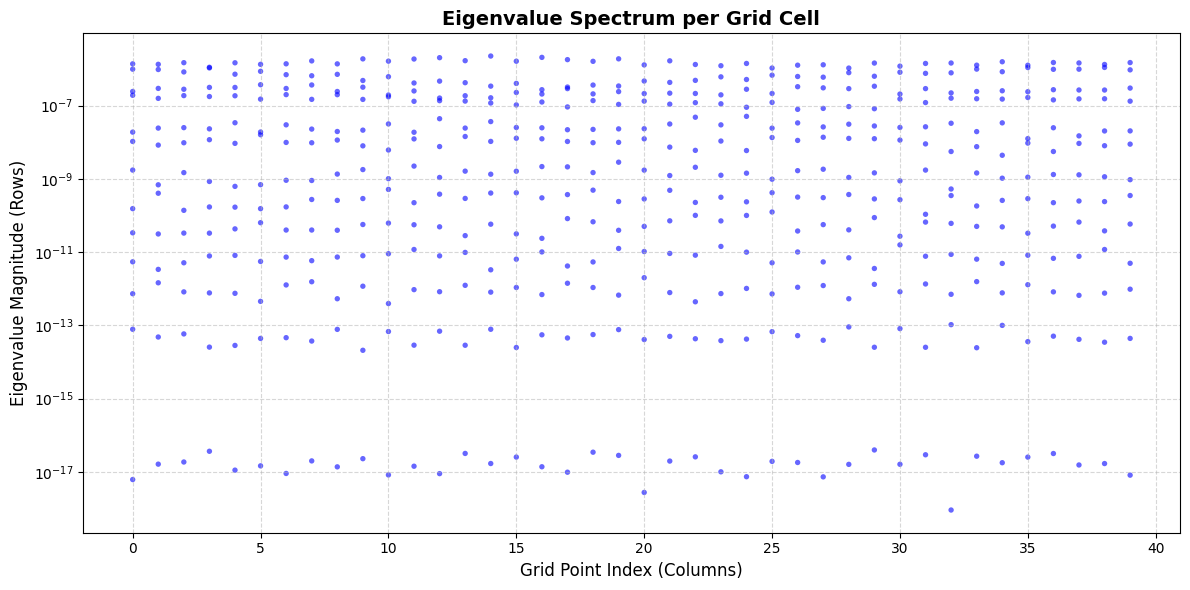

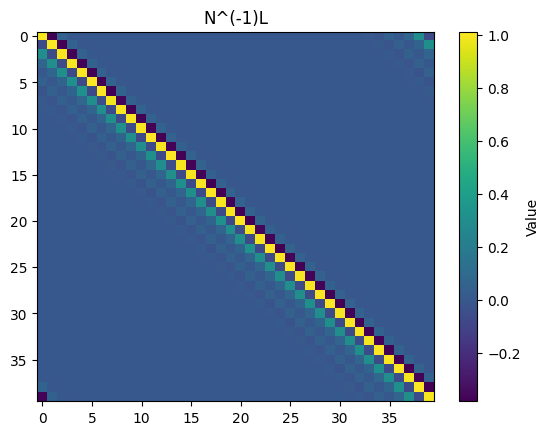

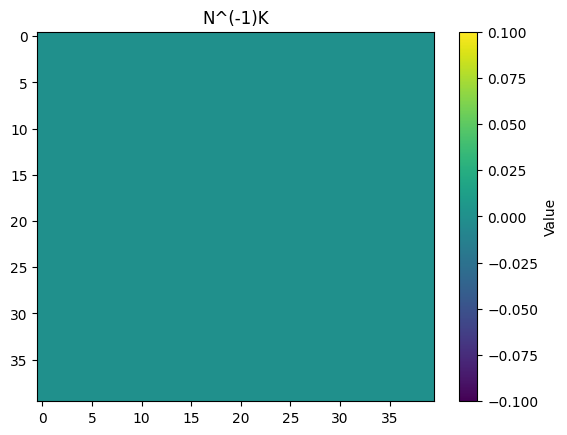

In [36]:
# Now that we have our ensembles we need to find the GETLM for each time step
TLMS = []

for i in range(len(Ensembles)-1):
    Chi = Ensembles[i+1][0]
    Xi = Ensembles[i+1][1]
    X = Ensembles[i+1][2]
    k = 1 # number of zero eigenvalue eigenvalues
    N_tilde, L_tilde, K_tilde = GETLM_generator(Chi, Xi, X, stencil_members_large, model_parameters, ensemble_size, k, plot = True)
    TLMS.append([N_tilde, L_tilde, K_tilde])
    plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
    plt.colorbar(label='Value')
    plt.title("2D Tensor Heatmap")
    plt.title("N^(-1)L")
    plt.show()
    plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
    plt.colorbar(label='Value')
    plt.title("2D Tensor Heatmap")
    plt.title("N^(-1)K")
    plt.show()


2


RuntimeError: mat1 and mat2 shapes cannot be multiplied (40x80 and 40x1)

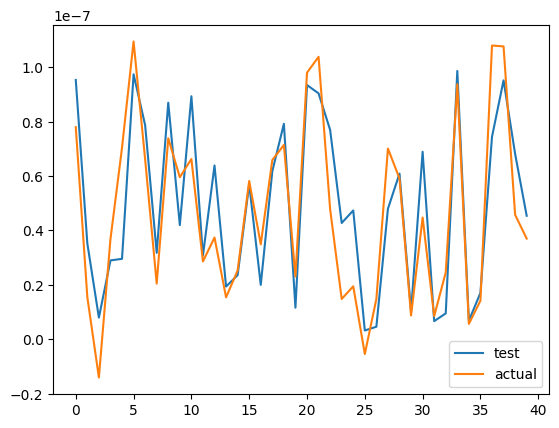

In [37]:
x_values = np.arange(1, N+1)  
test_pert = test_results[0]
print(len(test_pert))
test_out = torch.cat((test_pert[0], test_pert[1]))
for i in range(len(Ensembles)-1):

    N_tilde = TLMS[i][0]
    L_tilde = TLMS[i][0]
    K_tilde = TLMS[i][0]

    GETLM = torch.cat(((torch.pinverse(N_tilde) @ L_tilde).squeeze(), (torch.pinverse(N_tilde) @ K_tilde).squeeze()), dim = 1)
    test_out = GETLM @ test_out
    test_actual = test_results[i+1][0]
    test_np = test_out.detach().cpu().numpy() 
    plt.plot(test_out, label = 'test')
    plt.plot(test_actual, label = 'actual')
    plt.legend()



    

    


    

In [ ]:
print(len(test_results))
print(len(Ensembles))

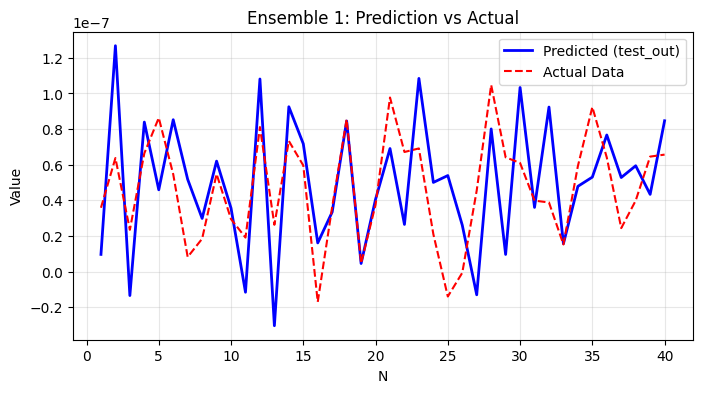

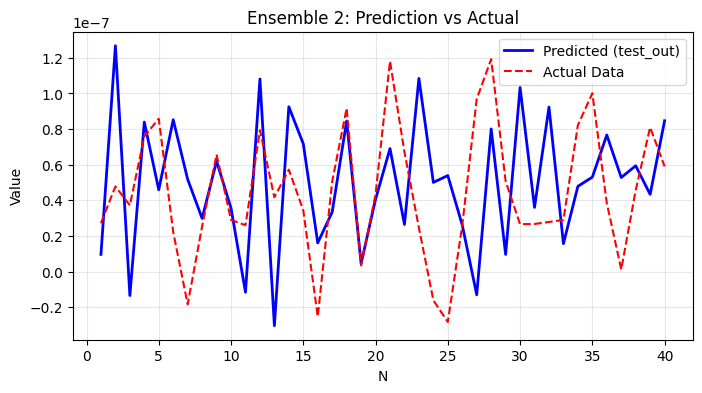

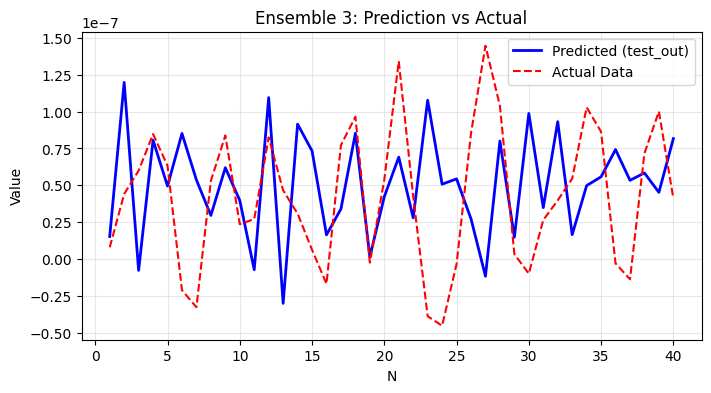

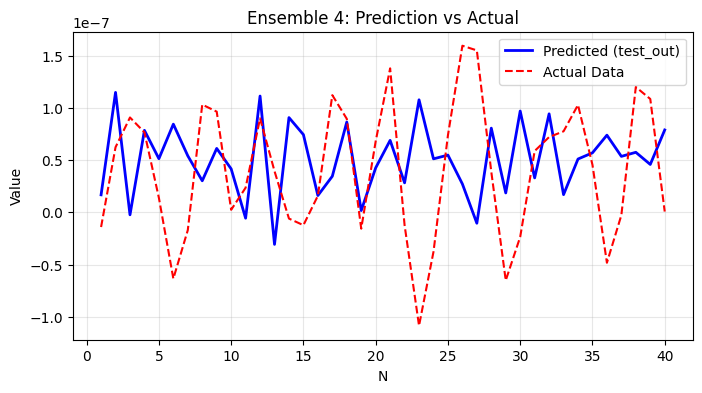

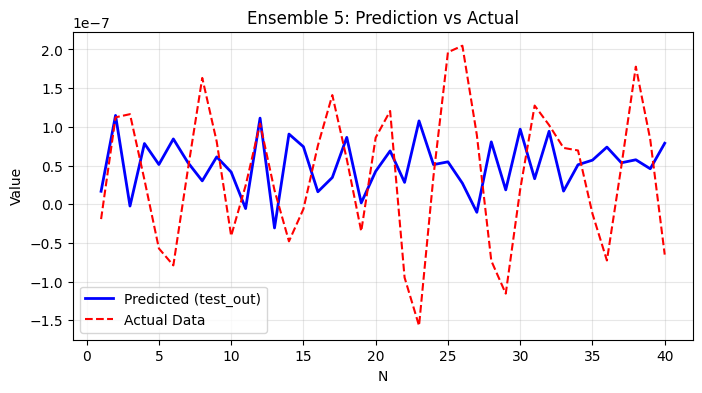

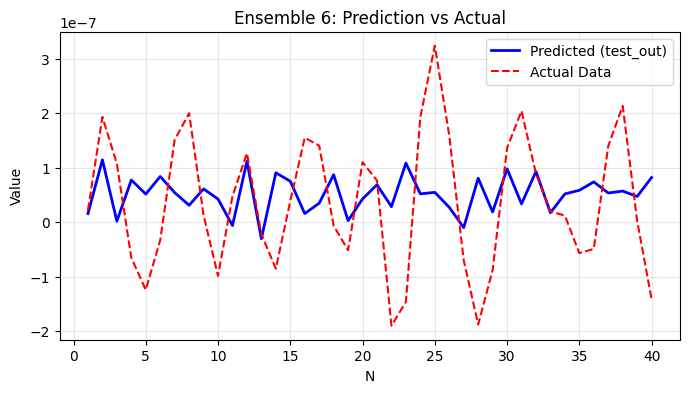

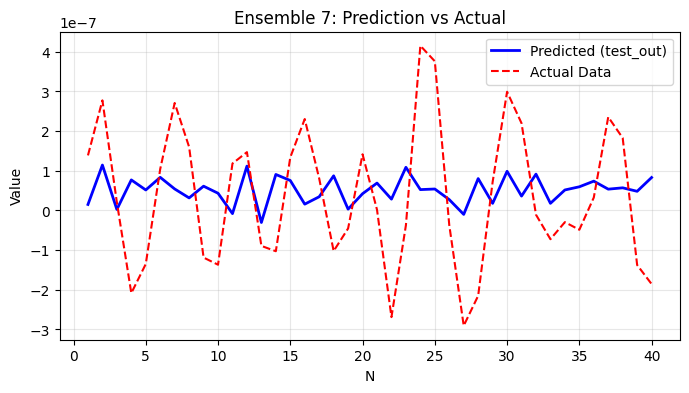

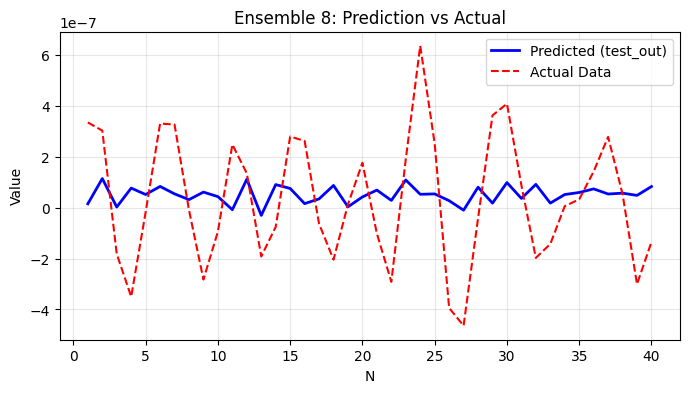

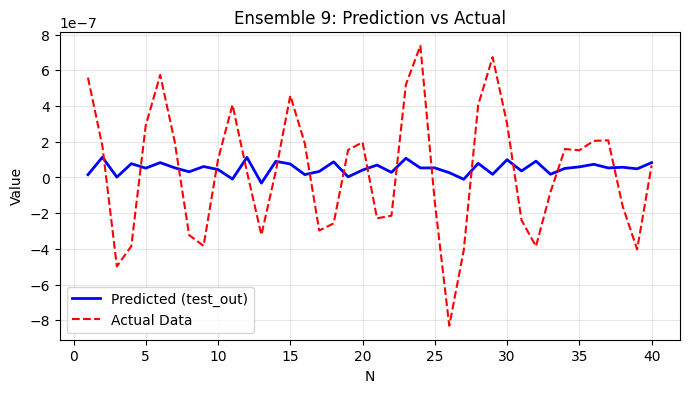

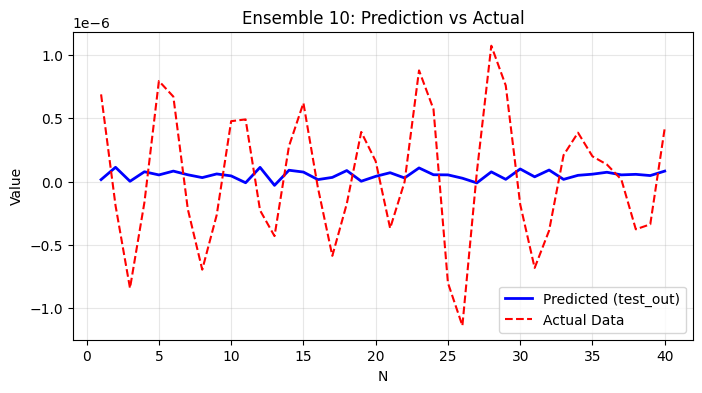

IndexError: list index out of range

In [ ]:


# 1. Initialize 
x_values = np.arange(1, N + 1)
test_pert = test_results[0]
# Initial state (length 80)
current_test_state = torch.cat((test_pert[0], test_pert[1])).flatten()

# print(test_pert)
for i in range(len(Ensembles) - 1):
    # Setup matrices (Double check your TLMS indices here!)
    N_tilde = TLMS[i][0]
    L_tilde = TLMS[i][1] 
    K_tilde = TLMS[i][2]

    # Calculate GETLM (Result: 40 x 80)
    GETLM = torch.cat(((torch.pinverse(N_tilde) @ L_tilde).squeeze(), 
                       (torch.pinverse(N_tilde) @ K_tilde).squeeze()), dim=1)
    
    # 2. Project state: [40, 80] @ [80] -> [40]
    # We use a temporary variable so we don't overwrite the '80' length needed for the next loop
    test_out = GETLM @ current_test_state
    test_actual = test_results[i+1][0].flatten()

    # 3. Plotting
    plt.figure(figsize=(8, 4))
    
    # Convert tensors to numpy for plotting
    # Use .detach().cpu() to ensure it works regardless of device/autograd
    plt.plot(x_values, test_out.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
    plt.plot(x_values, test_actual.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    
    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop